In [47]:
import os
import pandas as pd
import seaborn as sn
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests
import sidrapy
from ibge.localidades import *
from datetime import datetime
# import torch

# Importando os dados da base WSUS

Os dados são obtidos de um arquivo csv já tratado, caso não tenha o arquivo ele será criado automaticamente pelo script que executará ambas etapas:

- Converter o arquivo .dbc em .csv, gerando o arquivo `HANSENIASE_TOTAL_`

- Pré-processamento dos dados do Wsus¹ gerando o csv já tratado `HANSENIASE_PROCESS_`

In [48]:
print("-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------")
arquivos = []
path_csv = os.path.join('.', 'data', 'HANS')

# Garantir que o diretório existe
if not os.path.exists(path_csv):
    print(f"Diretório não encontrado: {path_csv}")
    os.makedirs(path_csv)  # Criar o diretório se não existir

# Verificar arquivos no diretório
for f in os.listdir(path_csv):
    if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
        try:
            # Extrair data do nome do arquivo
            data_str = f.split('_')[-3:]  # Pega os últimos 3 elementos (dd, mm, yyyy)
            data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
            arquivos.append((data, f))
        except Exception as e:
            print(f"Arquivo com formato inválido: {f} - {e}")

# Executar script externo se nenhum arquivo for encontrado
if not arquivos:
    print("Nenhum arquivo encontrado. Executando script para gerar arquivo...")
    path_gerar_wsus = os.path.join('.', 'gerar_wsus_csv.py')
    resultado = os.system('python ' + path_gerar_wsus)
    
    if resultado == 0:
        print("Script executado com sucesso. Verificando novo arquivo...")
        # Recarregar lista de arquivos após execução do script
        for f in os.listdir(path_csv):
            if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
                try:
                    data_str = f.split('_')[-3:]
                    data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
                    arquivos.append((data, f))
                except Exception as e:
                    print(f"Erro ao processar novo arquivo: {f} - {e}")
    else:
        print("Erro na execução do script. Arquivo não gerado.")

# Exibir lista final de arquivos encontrados
print("Arquivos encontrados:", arquivos)

if arquivos:
    # Ordenar arquivos pela data mais recente
    arquivos.sort(reverse=True, key=lambda x: x[0])
    
    # Pegar arquivo mais recente
    ultimo_arquivo = os.path.join(path_csv, arquivos[0][1])
    
    print(f"Carregando arquivo mais recente: {ultimo_arquivo}")
    
    # Carregar dados
    df_dados = pd.read_csv(ultimo_arquivo, encoding='utf-8', low_memory=False)
    
    print("\nPrimeiras linhas do DataFrame:")
    print(f"\nTotal de registros: {len(df_dados):,}")
    print(f"Data de referência: {arquivos[0][0].strftime('%d/%m/%Y')}")
else:
    print("Nenhum arquivo válido encontrado na pasta")

df_dados.head()    

-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------
Arquivos encontrados: [(datetime.datetime(2025, 3, 7, 0, 0), 'HANSENIASE_PROCESS_07_03_2025.csv')]
Carregando arquivo mais recente: .\data\HANS\HANSENIASE_PROCESS_07_03_2025.csv

Primeiras linhas do DataFrame:

Total de registros: 984,035
Data de referência: 07/03/2025


,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_DIAG,ANO_NASC,NU_IDADE_N,CS_SEXO,...,CLASSOPERA_CAT,BACILOSCOP_CAT,ESQ_INI_N_CAT,CONTREG_CAT,NERVOSAFET_CAT,ESQ_ATU_N_CAT,DOSE_RECEB_CAT,EPIS_RACIO_CAT,CONTEXAM_CAT,TPALTA_N_CAT
0,2001-01-10,2001,41.0,410304,1359.0,2741474.0,2000-12-10,1942,4058,M,...,2,9,3,0,0,3,0,9,0,1
1,2001-01-17,2001,41.0,410940,1359.0,2741369.0,2000-12-23,1956,4044,M,...,2,9,3,3,0,3,0,9,2,1
2,2001-01-16,2001,41.0,410940,1359.0,2741369.0,2001-01-16,1968,4032,M,...,1,9,1,1,0,1,0,9,1,1
3,2001-01-08,2001,41.0,411780,1359.0,2743116.0,2001-01-08,1960,4040,F,...,2,9,3,3,0,3,0,9,3,1
4,2001-01-02,2001,41.0,411780,1359.0,2743116.0,2000-01-11,1968,4031,M,...,2,9,3,0,0,3,0,9,0,1


# Analises Graficas

## Ocorrências de casos

### Notificações por Mês

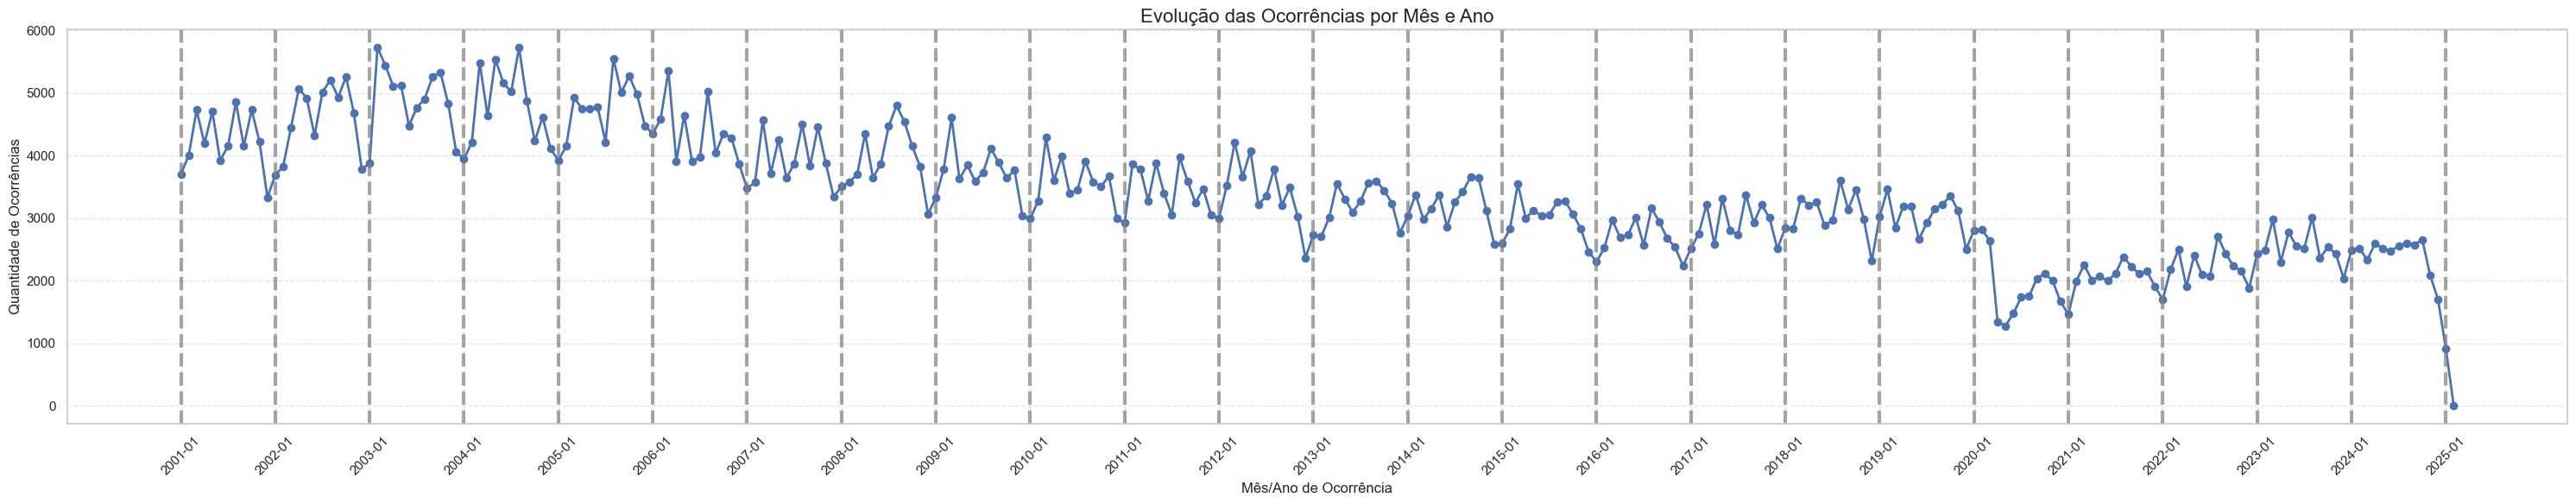

In [49]:
# Converter a coluna DT_NOTIFIC para datetime
df_dados["DT_NOTIFIC"] = pd.to_datetime(df_dados["DT_NOTIFIC"], format='%Y-%m-%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_dados["ANO_MES"] = df_dados["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar os dados por "ANO_MES" e contar a quantidade de ocorrências
dados_agrupados = df_dados.groupby("ANO_MES").size().reset_index(name="quantidade")

# Detectar mudanças de ano para adicionar linhas verticais
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].str[:4]
anos_unicos = dados_agrupados["ANO"].drop_duplicates().index

# Plotar o gráfico de linha com todos os pontos
fig, ax = plt.subplots(figsize=(30, 6))

ax.plot(
    dados_agrupados["ANO_MES"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 6 em 6 meses (somente legenda)
xticks = dados_agrupados["ANO_MES"][::12]  # Seleciona a cada 6 meses
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45)

# Adicionar linhas verticais nos inícios de cada ano
for ano_idx in anos_unicos:
    ax.axvline(x=ano_idx, color='gray', linestyle='--', linewidth=3, alpha=0.7)

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


### Notificações por Ano

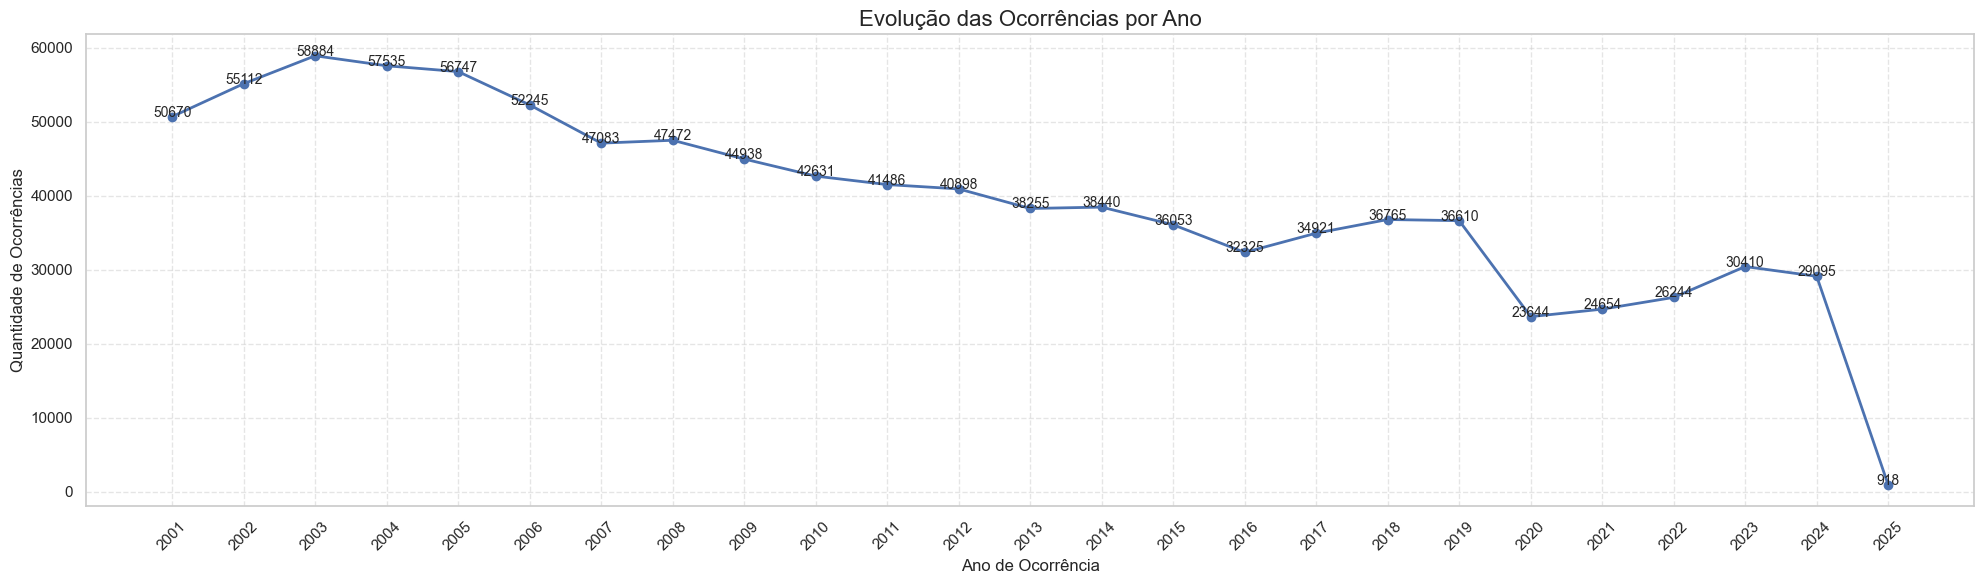

In [50]:
# Agrupar os dados por ano e contar a quantidade de ocorrências
dados_agrupados = df_dados.groupby("NU_ANO").size().reset_index(name="quantidade")

# Plotar o gráfico de linha com os anos no eixo X e a quantidade no eixo Y
fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(
    dados_agrupados["NU_ANO"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Ano", fontsize=16)
ax.set_xlabel("Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Adicionar rótulos nos pontos
for i, txt in enumerate(dados_agrupados["quantidade"]):
    ax.annotate(txt, (dados_agrupados["NU_ANO"][i], dados_agrupados["quantidade"][i]), fontsize=10, ha='center')

# Melhorar a aparência do gráfico
plt.xticks(dados_agrupados["NU_ANO"], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()

### Notificação por Estado

In [51]:
# Busco as informações dos estados
dados_estados = Estados()
if isinstance(dados_estados.json_ibge, (list, dict)):
    dt_est = dados_estados.json_ibge  # Já é uma estrutura Python válida
    print(dt_est)
else:
    dt_est = json.loads(dados_estados.json_ibge)  # Caso seja uma string JSON
    print(dt_est)
dt_est[17]

[{'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 12, 'sigla': 'AC', 'nome': 'Acre', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 13, 'sigla': 'AM', 'nome': 'Amazonas', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 14, 'sigla': 'RR', 'nome': 'Roraima', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 15, 'sigla': 'PA', 'nome': 'Pará', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 16, 'sigla': 'AP', 'nome': 'Amapá', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 17, 'sigla': 'TO', 'nome': 'Tocantins', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 21, 'sigla': 'MA', 'nome': 'Maranhão', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 22, 'sigla': 'PI', 'nome': 'Piauí', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 23, 'sigla': 'CE', 'nome': 'Ceará', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 24, 'si

{'id': 32,
 'sigla': 'ES',
 'nome': 'Espírito Santo',
 'regiao': {'id': 3, 'sigla': 'SE', 'nome': 'Sudeste'}}

In [52]:
# Extraindo corretamente as informações de estado e região
dados_est = []
for dado in dt_est:
    linha = {
        "id": dado["id"],
        "sigla": dado["sigla"],
        "nome": dado["nome"],
        "regiao": dado["regiao"]["nome"]  # Acessa o nome da região corretamente
    }
    dados_est.append(linha)

# Criar DataFrame com as informações de estados e regiões
df_estados = pd.DataFrame(dados_est)  
print(df_estados.head())



   id sigla      nome regiao
0  11    RO  Rondônia  Norte
1  12    AC      Acre  Norte
2  13    AM  Amazonas  Norte
3  14    RR   Roraima  Norte
4  15    PA      Pará  Norte


### Casos por Estado (Separado por Região)

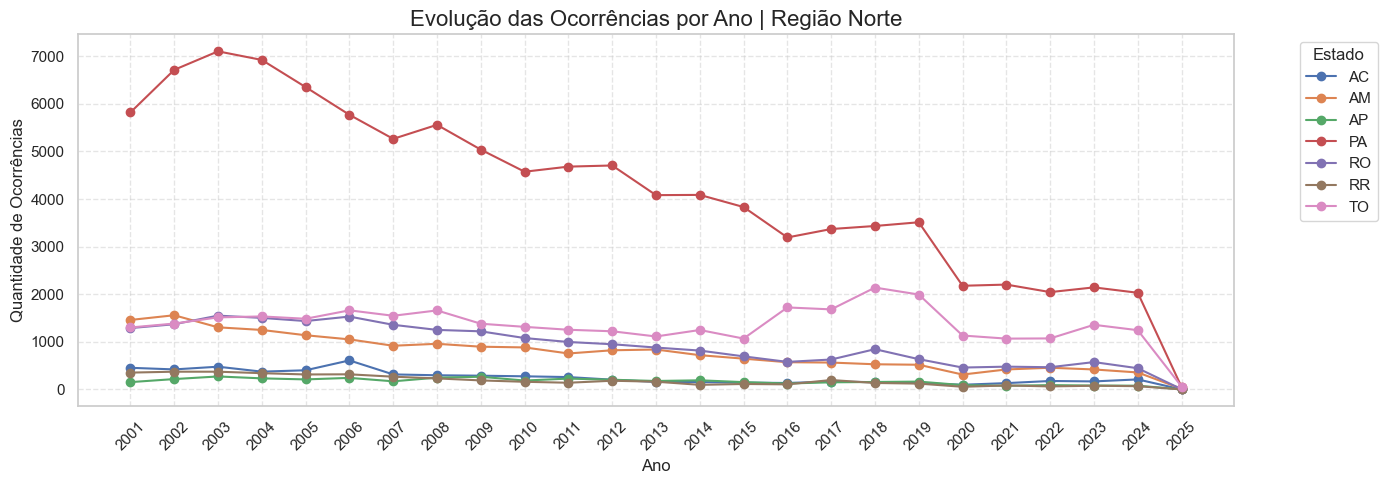

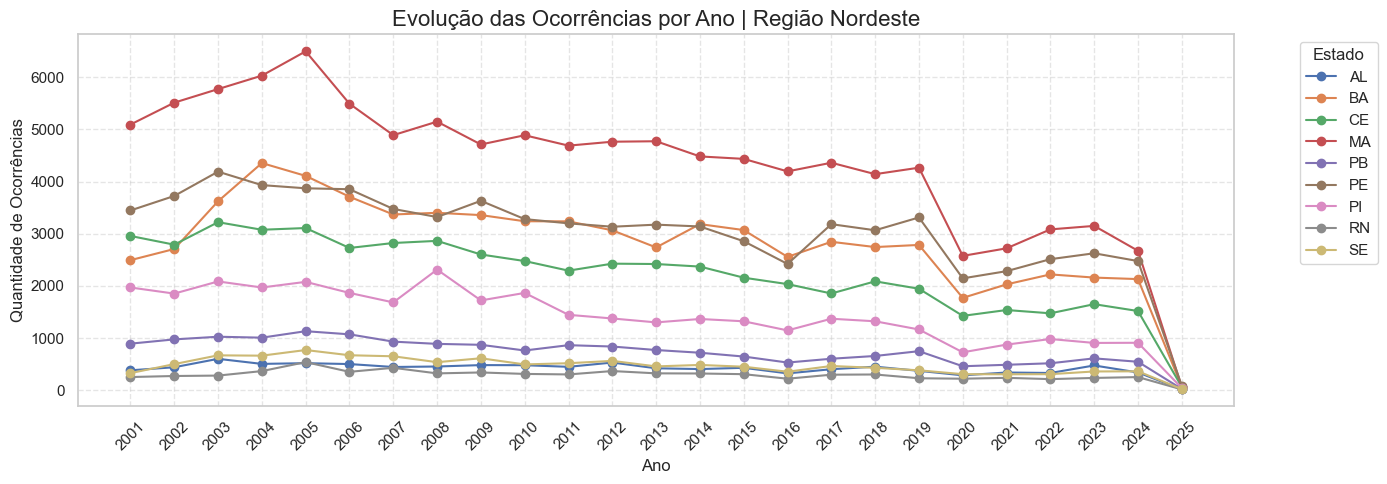

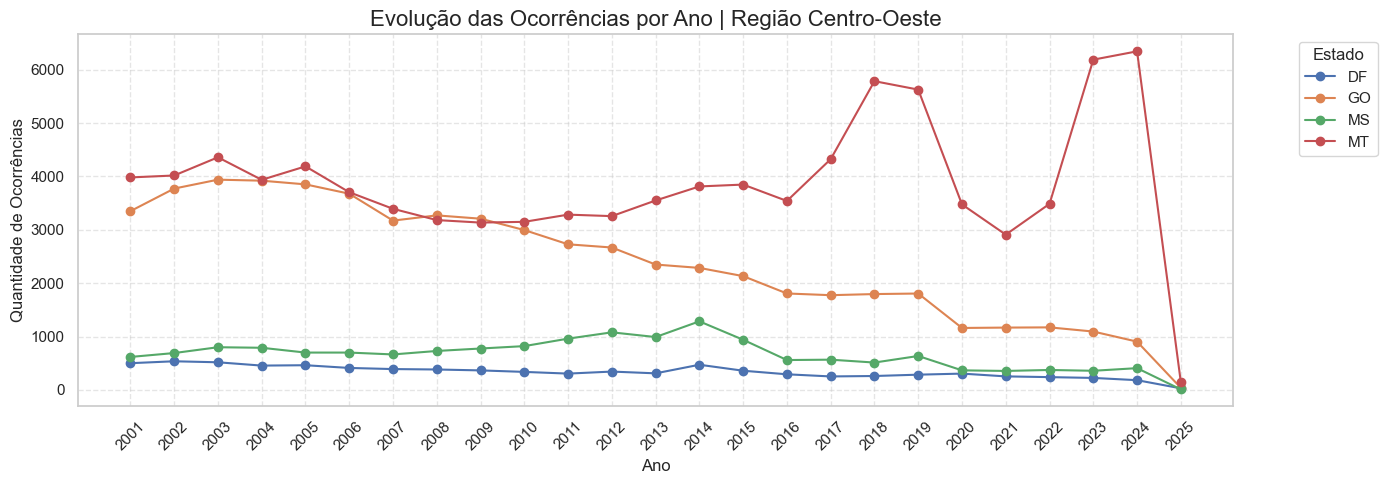

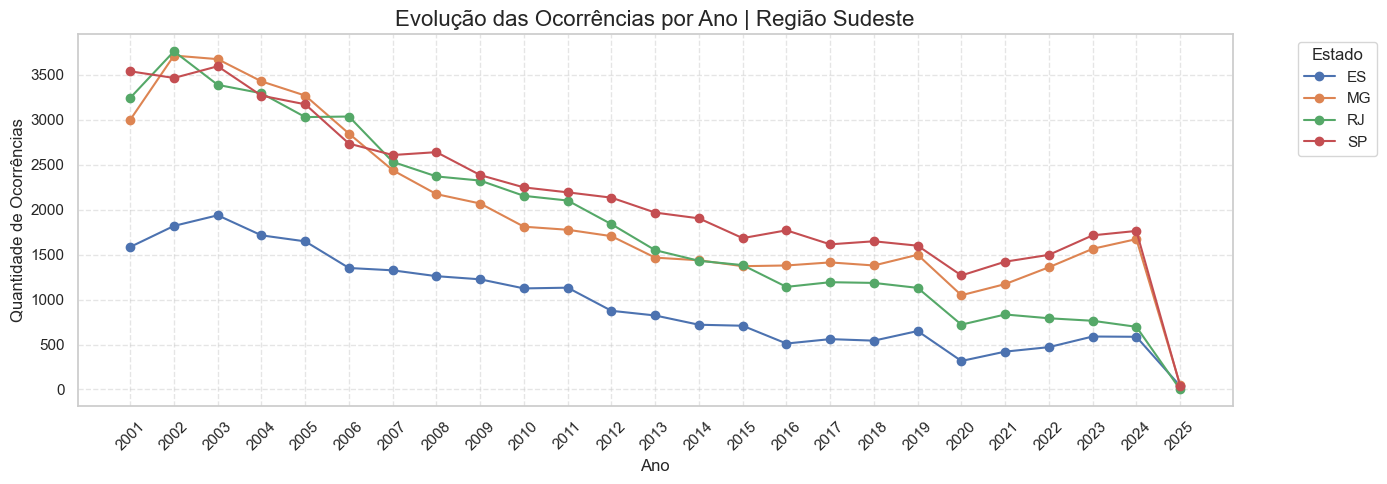

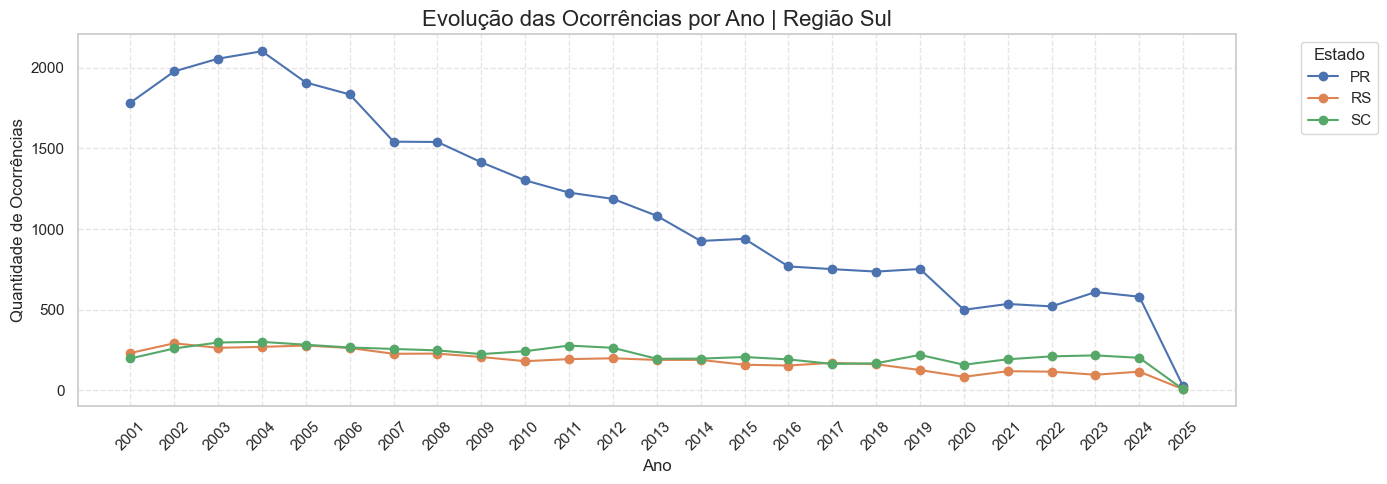

In [53]:
# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_dados.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano, estado e região
dados_agrupados = df_dados_estado.groupby(['NU_ANO', 'sigla', 'regiao']).size().reset_index(name='quantidade')

# Obter lista única de regiões
regioes = dados_agrupados['regiao'].unique()

# Criar gráficos de linha para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 5))

    dados_regiao = dados_agrupados[dados_agrupados['regiao'] == regiao]

    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['quantidade'],
            marker='o',
            label=estado
        )

    # Configurar títulos e rótulos
    ax.set_title(f'Evolução das Ocorrências por Ano | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Quantidade de Ocorrências', fontsize=12)

    # Melhorar a visualização
    plt.xticks(dados_agrupados['NU_ANO'].unique(), rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajustar o layout para evitar sobreposição
    plt.tight_layout()

    # Exibir o gráfico para a região atual
    plt.show()


### Por Região

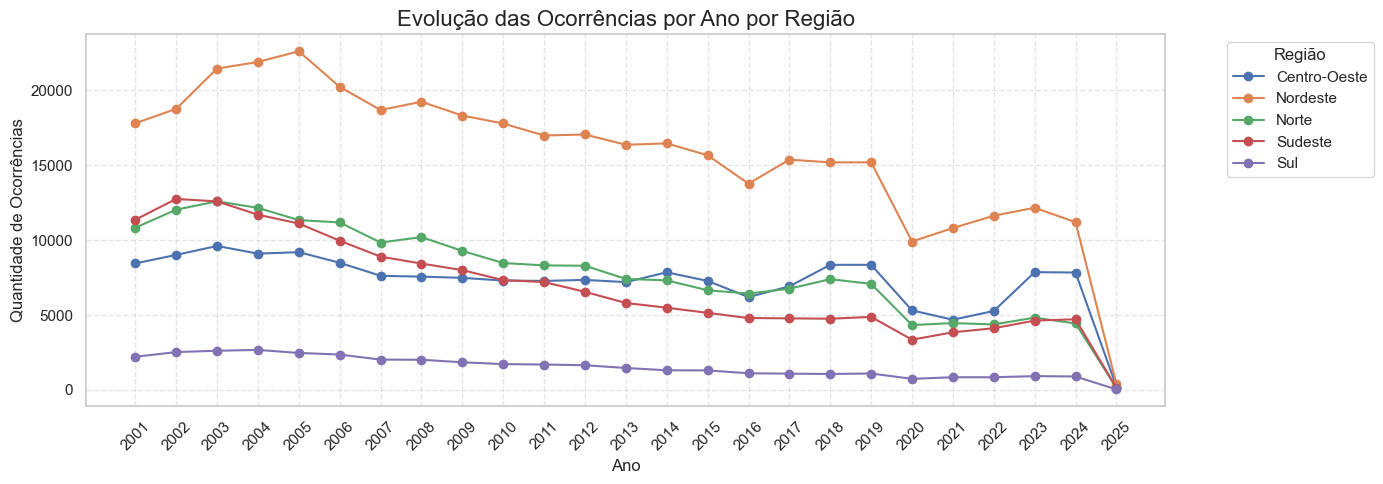

In [54]:
# Criar DataFrame de estados com regiões
df_estados = pd.DataFrame(dados_est)

# Adicionar a coluna de região ao DataFrame de dados com base no estado
df_dados_estado = df_dados.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano e região (agora sem separar por estado)
dados_agrupados_regiao = df_dados_estado.groupby(['NU_ANO', 'regiao']).size().reset_index(name='quantidade')

# Obter lista única de regiões
regioes = dados_agrupados_regiao['regiao'].unique()

# Criar um gráfico de linha para todos os dados por região
fig, ax = plt.subplots(figsize=(14, 5))

# Plotar as ocorrências totais para cada região ao longo dos anos
for regiao in regioes:
    dados_regiao = dados_agrupados_regiao[dados_agrupados_regiao['regiao'] == regiao]
    ax.plot(
        dados_regiao['NU_ANO'],
        dados_regiao['quantidade'],
        marker='o',
        label=regiao
    )

# Configurar o título e rótulos dos eixos
ax.set_title('Evolução das Ocorrências por Ano por Região', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_regiao['NU_ANO'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir legenda com as regiões
ax.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()


## Mortalidade

### Por Ano

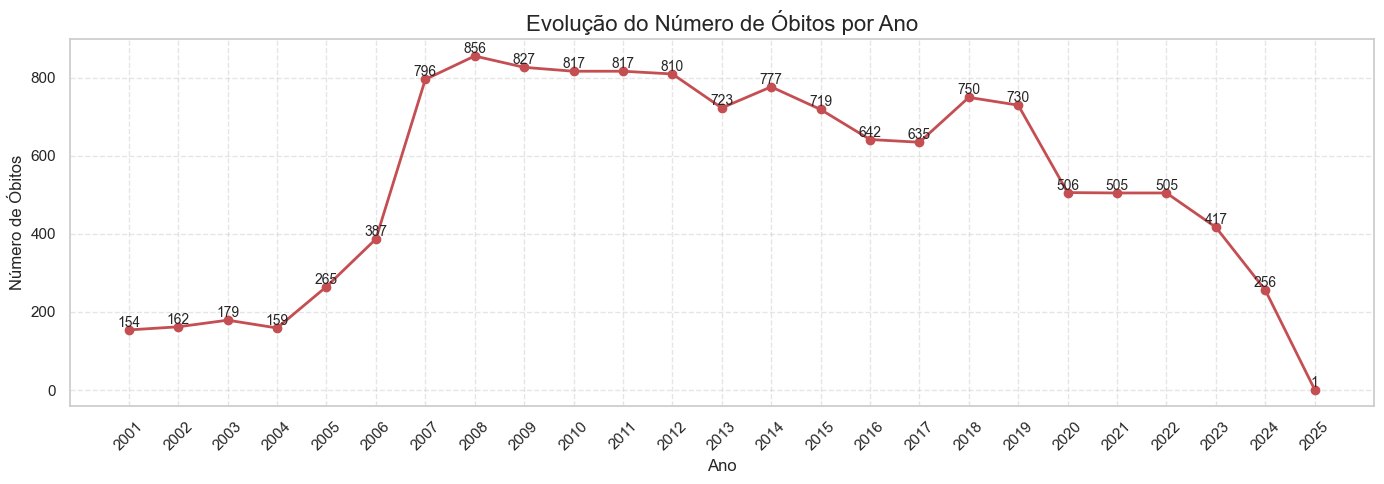

In [55]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4'].copy()

# Agrupar os dados por ano e contar a quantidade de óbitos
dados_agrupados_obitos = df_obitos.groupby('NU_ANO').size().reset_index(name='quantidade_obitos')

# Criar o gráfico de linha
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    dados_agrupados_obitos['NU_ANO'],
    dados_agrupados_obitos['quantidade_obitos'],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='r'  # Cor vermelha para óbitos
)

# Adicionar os números de óbitos nos pontos do gráfico
for i, txt in enumerate(dados_agrupados_obitos['quantidade_obitos']):
    ax.annotate(txt, (dados_agrupados_obitos['NU_ANO'][i], dados_agrupados_obitos['quantidade_obitos'][i]),
                fontsize=10, ha='center', va='bottom')

# Configurar título e rótulos dos eixos
ax.set_title('Evolução do Número de Óbitos por Ano', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Número de Óbitos', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_obitos['NU_ANO'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()


### Por Mês 

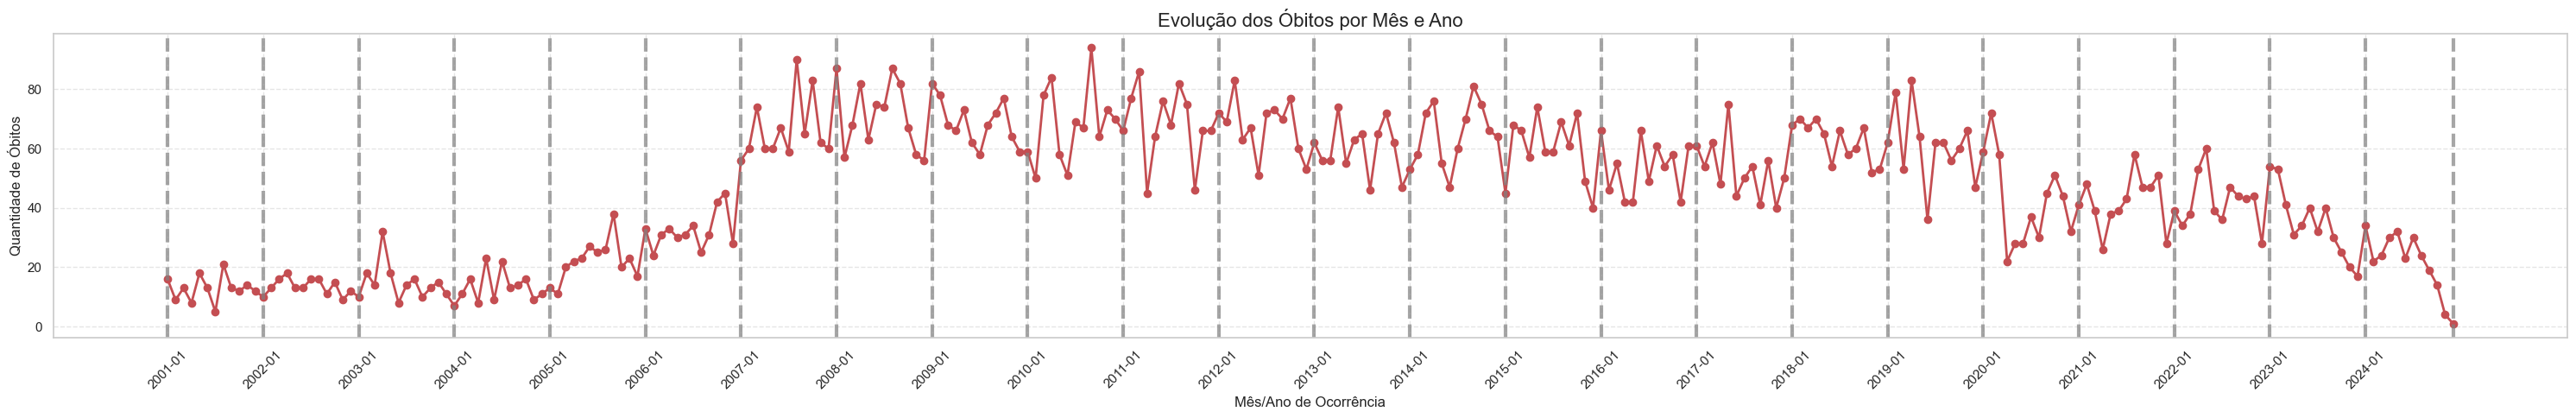

In [56]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4'].copy()  # Usar .copy() para evitar o aviso

# Converter a coluna DT_NOTIFIC para datetime
df_obitos.loc[:, "DT_NOTIFIC"] = pd.to_datetime(df_obitos["DT_NOTIFIC"], format='%Y%m%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_obitos.loc[:, "ANO_MES"] = df_obitos["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar os dados por "ANO_MES" e contar a quantidade de óbitos
dados_agrupados_obitos = df_obitos.groupby("ANO_MES").size().reset_index(name="quantidade_obitos")

# Detectar mudanças de ano para adicionar linhas verticais
dados_agrupados_obitos["ANO"] = dados_agrupados_obitos["ANO_MES"].str[:4]
anos_unicos = dados_agrupados_obitos["ANO"].drop_duplicates().index

# Plotar o gráfico de linha com todos os pontos
fig, ax = plt.subplots(figsize=(30, 5))

ax.plot(
    dados_agrupados_obitos["ANO_MES"],
    dados_agrupados_obitos["quantidade_obitos"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='r'  # Cor vermelha para óbitos
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução dos Óbitos por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Óbitos", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 6 em 6 meses (somente legenda)
xticks = dados_agrupados_obitos["ANO_MES"][::12]  # Seleciona a cada 12 meses (1 ano)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45)

# Adicionar linhas verticais nos inícios de cada ano
for ano_idx in anos_unicos:
    ax.axvline(x=ano_idx, color='gray', linestyle='--', linewidth=3, alpha=0.7)

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


### Por Estado

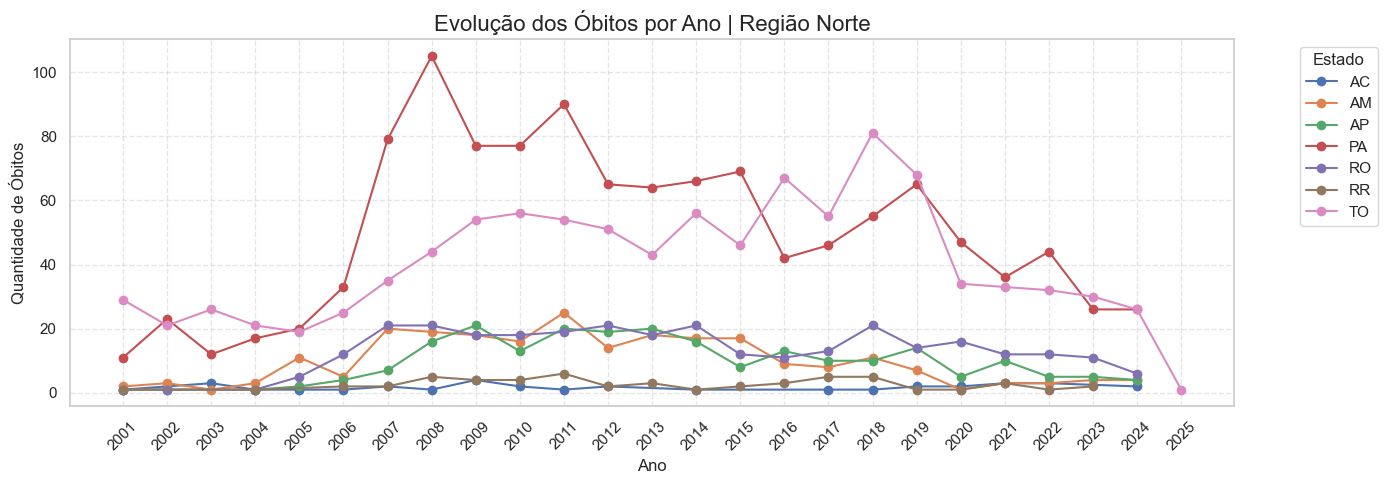

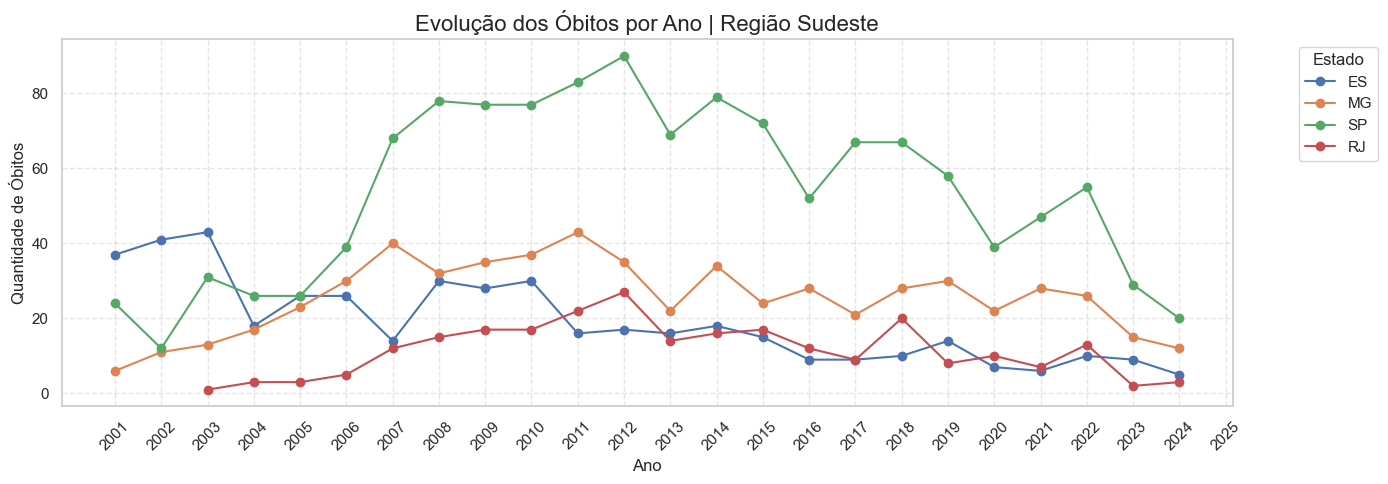

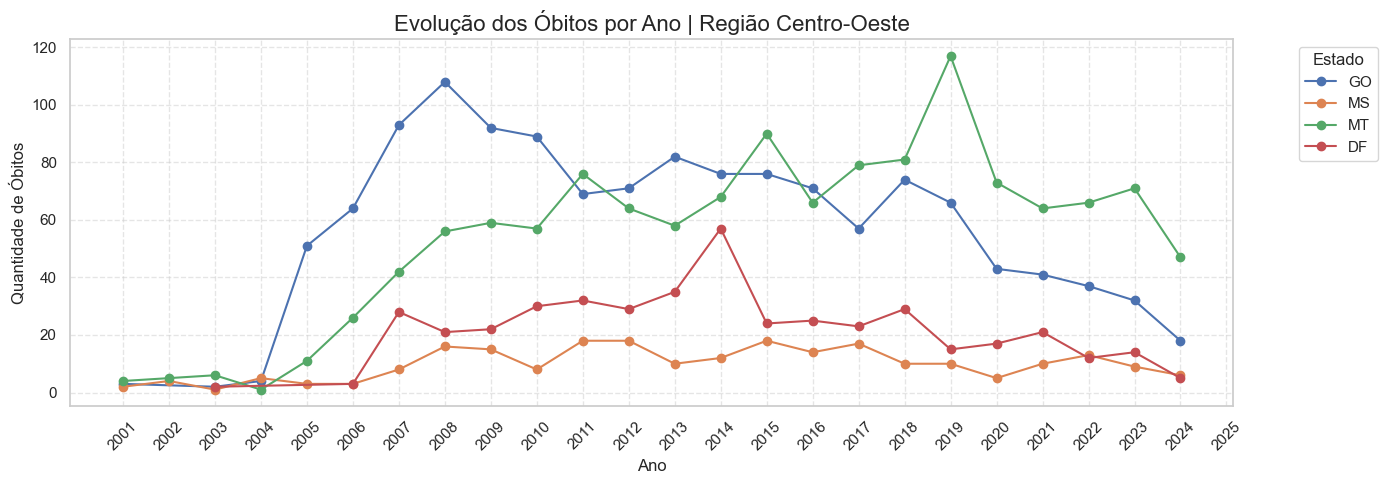

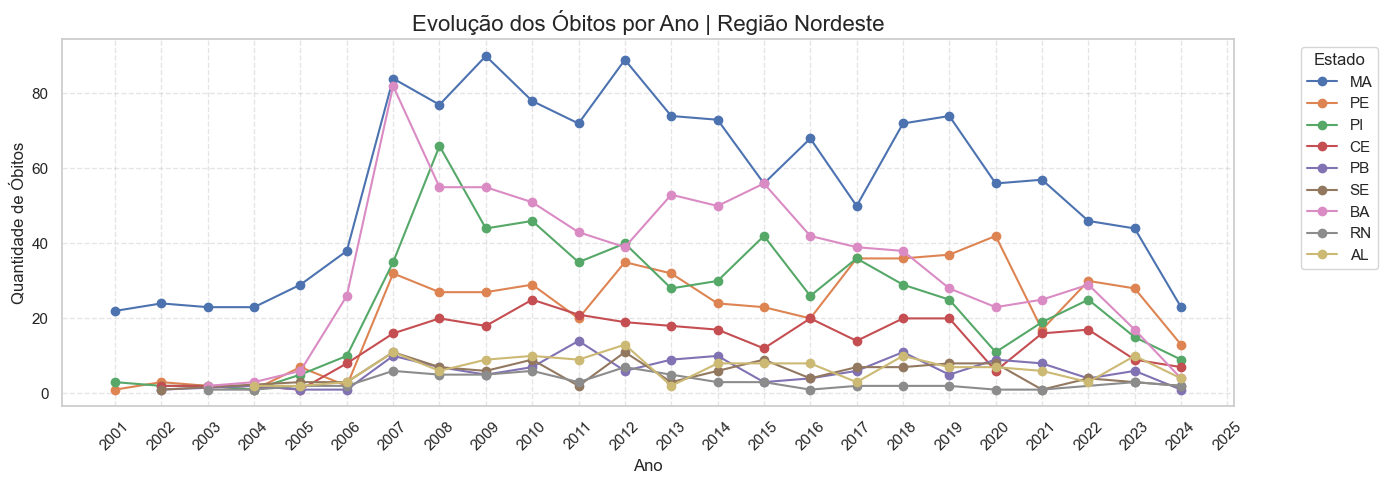

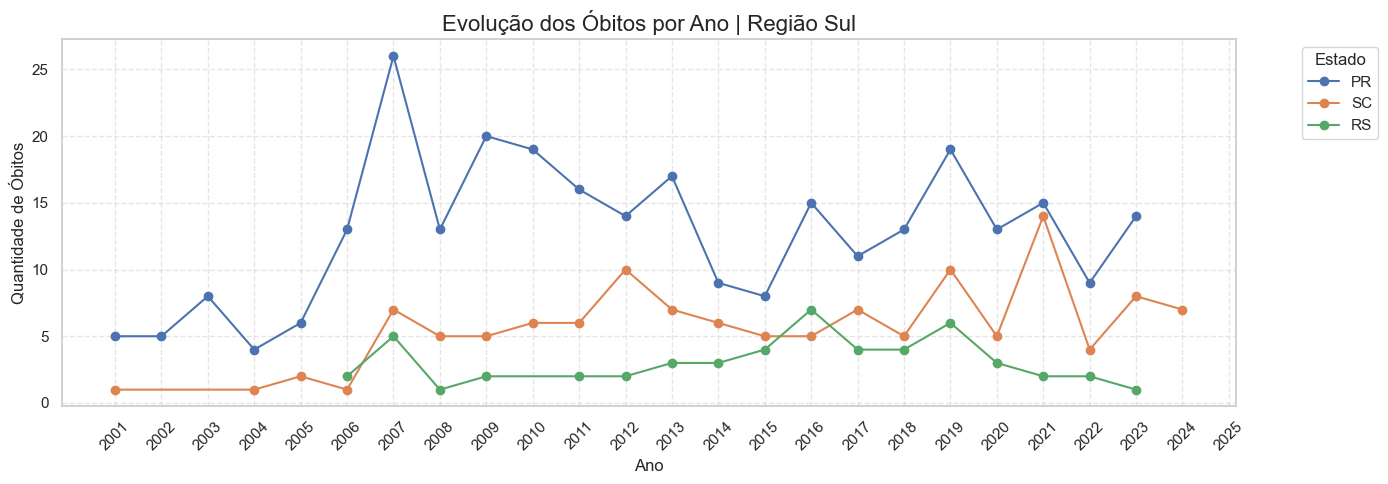

In [57]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4'].copy()  # Usar .copy() para evitar o aviso

# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_obitos.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano, estado e região para óbitos
dados_agrupados_obitos = df_dados_estado.groupby(['NU_ANO', 'sigla', 'regiao']).size().reset_index(name='quantidade_obitos')

# Obter lista única de regiões
regioes = dados_agrupados_obitos['regiao'].unique()

# Criar gráficos de linha para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 5))

    dados_regiao = dados_agrupados_obitos[dados_agrupados_obitos['regiao'] == regiao]

    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['quantidade_obitos'],
            marker='o',
            label=estado
        )

    # Configurar títulos e rótulos
    ax.set_title(f'Evolução dos Óbitos por Ano | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Quantidade de Óbitos', fontsize=12)

    # Melhorar a visualização
    plt.xticks(dados_agrupados_obitos['NU_ANO'].unique(), rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajustar o layout para evitar sobreposição
    plt.tight_layout()

    # Exibir o gráfico para a região atual
    plt.show()


### Por Região

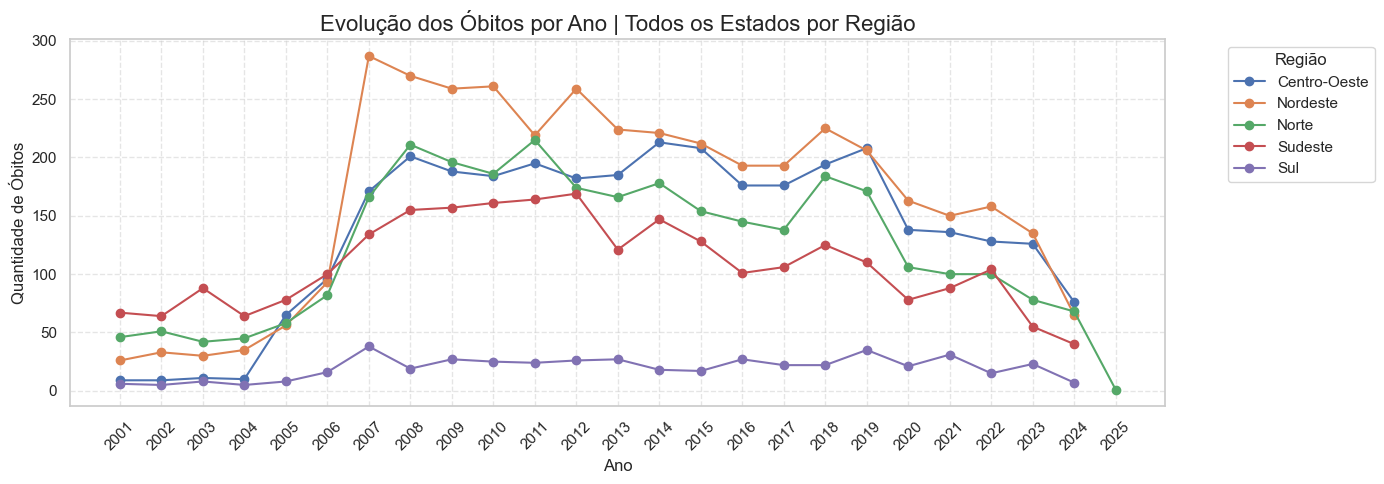

In [58]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4'].copy()  # Usar .copy() para evitar o aviso

# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_obitos.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano e região para óbitos
dados_agrupados_obitos = df_dados_estado.groupby(['NU_ANO', 'regiao']).size().reset_index(name='quantidade_obitos')

# Obter lista única de regiões
regioes = dados_agrupados_obitos['regiao'].unique()

# Criar gráfico de linha para cada região, com a soma dos óbitos por ano
fig, ax = plt.subplots(figsize=(14, 5))

# Para cada região, plotar os dados de óbitos
for regiao in regioes:
    dados_regiao = dados_agrupados_obitos[dados_agrupados_obitos['regiao'] == regiao]
    ax.plot(
        dados_regiao['NU_ANO'],
        dados_regiao['quantidade_obitos'],
        marker='o',
        label=regiao
    )

# Configurar título e rótulos
ax.set_title('Evolução dos Óbitos por Ano | Todos os Estados por Região', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade de Óbitos', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_obitos['NU_ANO'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar o layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico para as regiões
plt.show()


# Predição

### Analise de Variaveis (Verificar)

In [98]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Selecionando features para predição
features_pred = ['IDADE_ANOS', 'NU_LESOES_CAT', 'DOSE_RECEB_CAT', 'EPIS_RACIO_CAT', 'FORMACLINI_CAT']
df = df_dados.copy()
# Preparando os dados
X = df[features_pred]
y = df['CLASSATUAL_CAT']

# Dividindo em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando o modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Fazendo predições
y_pred = rf_model.predict(X_test)

# Avaliando o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo: {accuracy:.2f}')

# Importância das features
importances = pd.DataFrame({'feature':features_pred, 'importance':rf_model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
print(importances)


Acurácia do modelo: 0.95
          feature  importance
4  FORMACLINI_CAT    0.610350
2  DOSE_RECEB_CAT    0.210288
1   NU_LESOES_CAT    0.132552
0      IDADE_ANOS    0.037911
3  EPIS_RACIO_CAT    0.008899


#### Importancia das variaveis

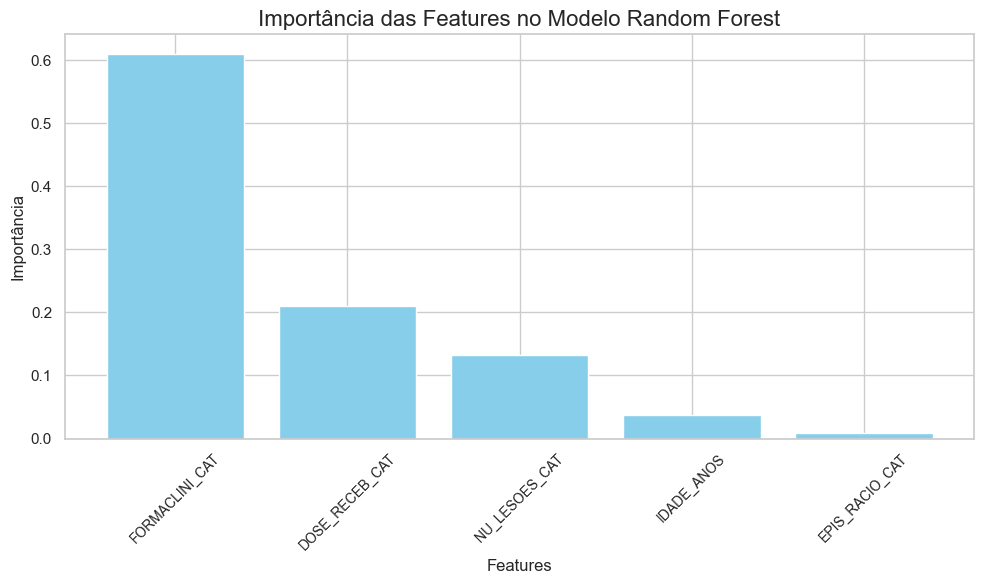

In [99]:
# Visualizando a importância das features graficamente
plt.figure(figsize=(10, 6))
plt.bar(importances['feature'], importances['importance'], color='skyblue')
plt.title('Importância das Features no Modelo Random Forest', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importância', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()


## Serie Temporal

### Criando databases

#### Dados Agrupados

##### Função Dados Agrupados

In [100]:
def cria_dados_agrupados(df_dados):
    # Certifique-se de que a coluna DT_NOTIFIC foi convertida para datetime
    df = df_dados.copy()
    df["DT_NOTIFIC"] = pd.to_datetime(df["DT_NOTIFIC"], format='%Y-%m-%d', errors='coerce')

    # Criar uma nova coluna no formato "AAAA-MM"
    df["ANO_MES"] = df["DT_NOTIFIC"].dt.to_period("M").astype(str)

    # Agrupar por "ANO_MES" e contar as ocorrências
    dados_agrupados = df.groupby("ANO_MES").size().reset_index(name="quantidade")

    return dados_agrupados

##### Visualização dos dados

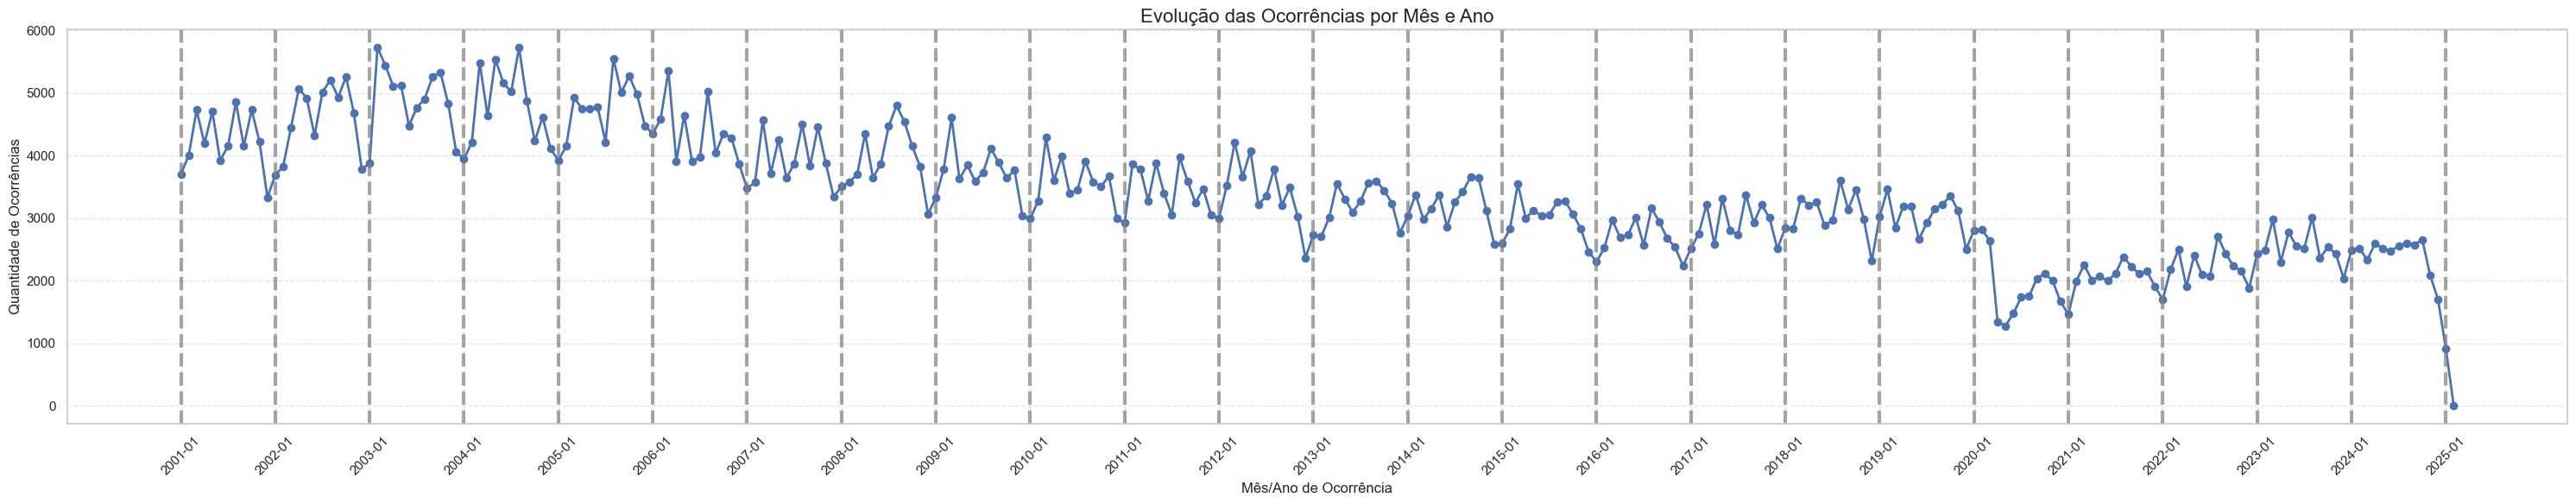

In [101]:
df = df_dados.copy()
dados_agrupados = cria_dados_agrupados(df_dados)

# Detectar mudanças de ano para adicionar linhas verticais
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].str[:4]
anos_unicos = dados_agrupados["ANO"].drop_duplicates().index

# Plotar o gráfico de linha com todos os pontos
fig, ax = plt.subplots(figsize=(30, 6))

ax.plot(
    dados_agrupados["ANO_MES"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 6 em 6 meses (somente legenda)
xticks = dados_agrupados["ANO_MES"][::12]  # Seleciona a cada 6 meses
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45)

# Adicionar linhas verticais nos inícios de cada ano
for ano_idx in anos_unicos:
    ax.axvline(x=ano_idx, color='gray', linestyle='--', linewidth=3, alpha=0.7)
   

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()



#### Dados Prophet

##### Função Dados Prophet

In [102]:
def cria_dt_prophet(df): 
    # Converter a coluna DT_NOTIFIC para datetime
    df["DT_NOTIFIC"] = pd.to_datetime(df["DT_NOTIFIC"], format='%Y-%m-%d', errors='coerce')

    # Criar uma nova coluna no formato "AAAA-MM"
    df['ANO_MES'] = df['DT_NOTIFIC'].dt.to_period('M').astype(str)

    # Agrupar os dados por "ANO_MES" e calcular as médias e contagens necessárias
    df_prophet = df.groupby('ANO_MES').agg({
        'IDADE_ANOS': 'mean',
        'NU_LESOES_CAT': 'mean',
        'NERVOSAFET_CAT': 'mean',
        'DOSE_RECEB_CAT': 'mean',
        'ID_MUNICIP': 'count'  # Contagem de casos
    }).reset_index()

    # Renomear as colunas conforme exigido pelo Prophet
    df_prophet = df_prophet.rename(columns={
        'ANO_MES': 'ds',
        'ID_MUNICIP': 'y',
        'IDADE_ANOS': 'idade_media',
        'NU_LESOES_CAT': 'lesoes_media',
        'NERVOSAFET_CAT': 'nervos_afetados_media',
        'DOSE_RECEB_CAT': 'doses_recebidas_media'
    })

    # Converter a coluna 'ds' para datetime
    df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

    return df_prophet

##### Visualização dos dados Prophet

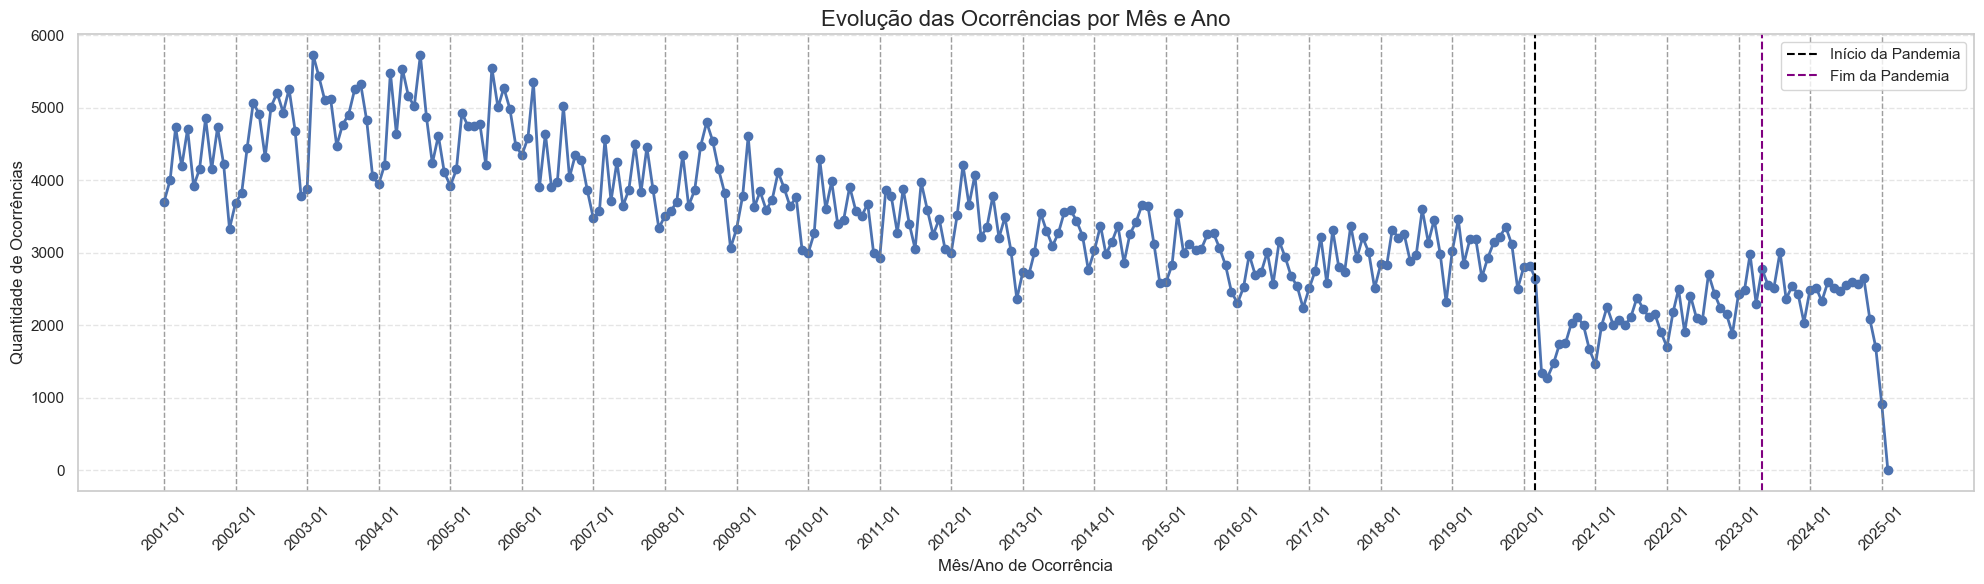

In [103]:
# Assumindo que df_dados já está carregado
df = df_dados.copy()

# Assumindo que df_dados já está carregado
df_prophet = cria_dt_prophet(df)

# Criar o gráfico
fig, ax = plt.subplots(figsize=(20, 6))

# Plotar a linha principal
ax.plot(
    df_prophet["ds"],
    df_prophet["y"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 12 em 12 meses
xticks = df_prophet["ds"][::12]  # Seleciona a cada 12 meses
ax.set_xticks(xticks)
ax.set_xticklabels([tick.strftime('%Y-%m') for tick in xticks], rotation=45)

# Detectar mudanças de ano para adicionar linhas verticais
anos_unicos = df_prophet["ds"].dt.year.drop_duplicates()
for ano in anos_unicos:
    data_ano = pd.to_datetime(f"{ano}-01-01")
    if data_ano in df_prophet["ds"].values:
        ax.axvline(x=data_ano, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Adicionar linhas verticais para início e fim da pandemia
ax.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
ax.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Adicionar legenda
plt.legend()

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()

### Prophet (Predição)

1- Linha do tempo principal:
    - Eixo X: Data de notificação (DT_NOTIFIC)
    - Eixo Y: Número de casos notificados
2- Pontos sobrepostos à linha do tempo:
    - Cada ponto representa um caso individual
    - Tamanho do ponto: Número de lesões cutâneas (NU_LESOES)
    - Cor do ponto: Forma clínica (FORMACLINI)
3- Barras empilhadas abaixo da linha principal:
    - Representando a distribuição de classificação operacional (CLASSOPERA)
4- Linha secundária:
    - Mostrando a média móvel de doses recebidas (DOSE_RECEB)
5- Área sombreada:
    - Indicando o número de contatos examinados (CONTEXAM)

#### Prophet - Grafico interativo

13:51:34 - cmdstanpy - INFO - Chain [1] start processing
13:51:40 - cmdstanpy - INFO - Chain [1] done processing
d:\python\data_health\venv_health\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


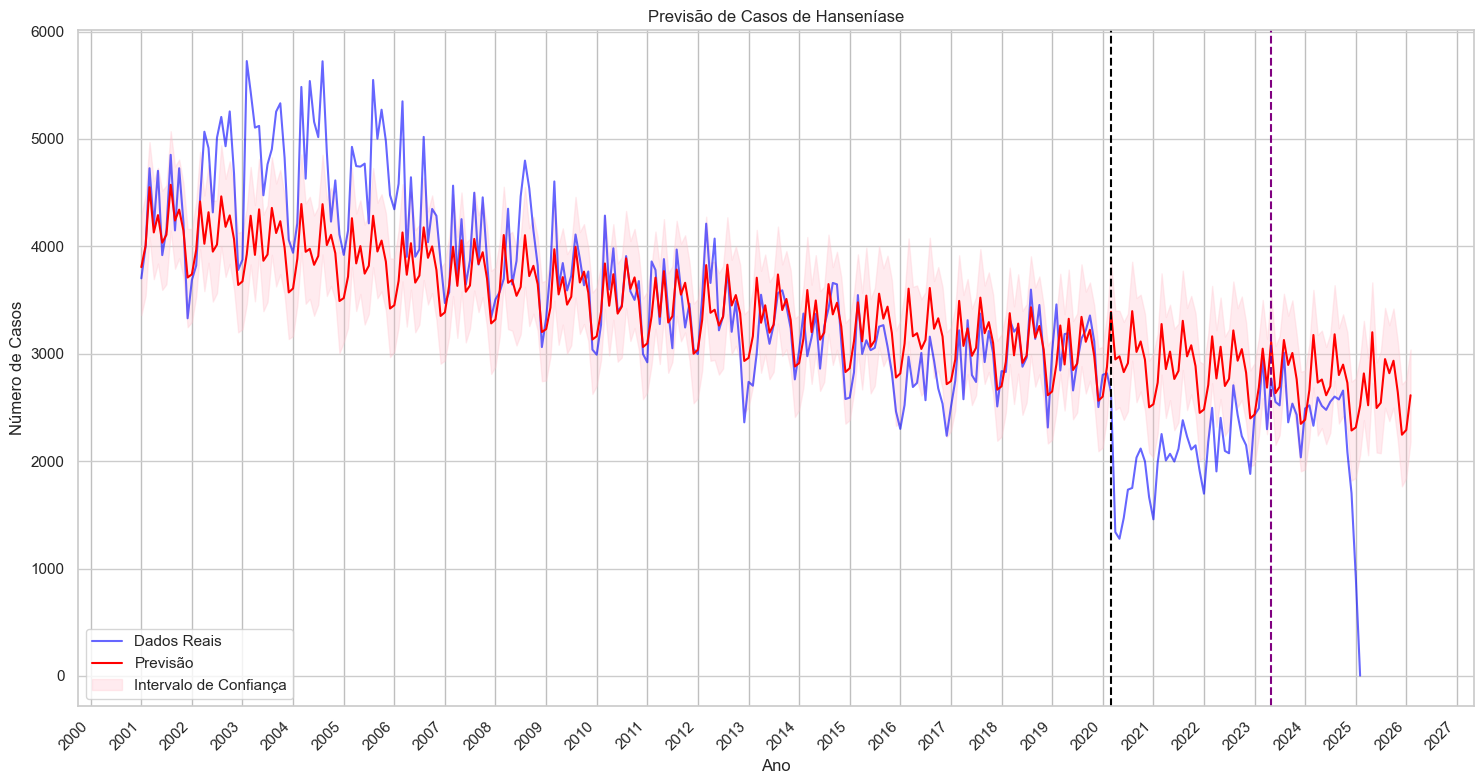

In [104]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Assumindo que df_dados já está carregado
df = df_dados.copy()

df_prophet = cria_dt_prophet(df)

# Criar e treinar o modelo
model = Prophet()
model.add_regressor('idade_media')
model.add_regressor('lesoes_media')
model.add_regressor('nervos_afetados_media')
model.add_regressor('doses_recebidas_media')

model.fit(df_prophet)

# Criar dataframe para previsão futura
future_dates = model.make_future_dataframe(periods=12, freq='M')  # Prever próximos 12 meses
future_dates['idade_media'] = df_prophet['idade_media'].mean()
future_dates['lesoes_media'] = df_prophet['lesoes_media'].mean()
future_dates['nervos_afetados_media'] = df_prophet['nervos_afetados_media'].mean()
future_dates['doses_recebidas_media'] = df_prophet['doses_recebidas_media'].mean()

# Fazer previsões
forecast = model.predict(future_dates)

# Configurar o gráfico
fig, ax = plt.subplots(figsize=(15, 8))

# Plotar dados reais
ax.plot(df_prophet['ds'], df_prophet['y'], color='blue', label='Dados Reais', alpha=0.6)

# Plotar previsão
ax.plot(forecast['ds'], forecast['yhat'], color='red', label='Previsão')

# Adicionar intervalo de confiança
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='pink', alpha=0.3, label='Intervalo de Confiança')

# Configurar eixo x
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.xaxis.set_minor_locator(months)

# Adicionar linhas de grade para cada ano
ax.grid(which='major', axis='x', linestyle='-', color='gray', alpha=0.5)

# Configurar labels e título
ax.set_xlabel('Ano')
ax.set_ylabel('Número de Casos')
ax.set_title('Previsão de Casos de Hanseníase')

# Adicionar legenda
ax.legend()

# Rotacionar labels do eixo x para melhor visualização
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")

# Ajustar o layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()



### Redes neurais

#### LSTM I (Verificar)

d:\python\data_health\venv_health\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - loss: 0.4753 - val_loss: 0.1645
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2771 - val_loss: 0.0346
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1263 - val_loss: 0.0491
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0515 - val_loss: 0.1748
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0475 - val_loss: 0.0536
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0270 - val_loss: 0.0262
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0141 - val_loss: 0.0212
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0088 - val_loss: 0.0137
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0090 - val_loss: 0.0114
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0083 - val_loss: 0.0119
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0082 - val_loss: 0.0118
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0080 - val_l

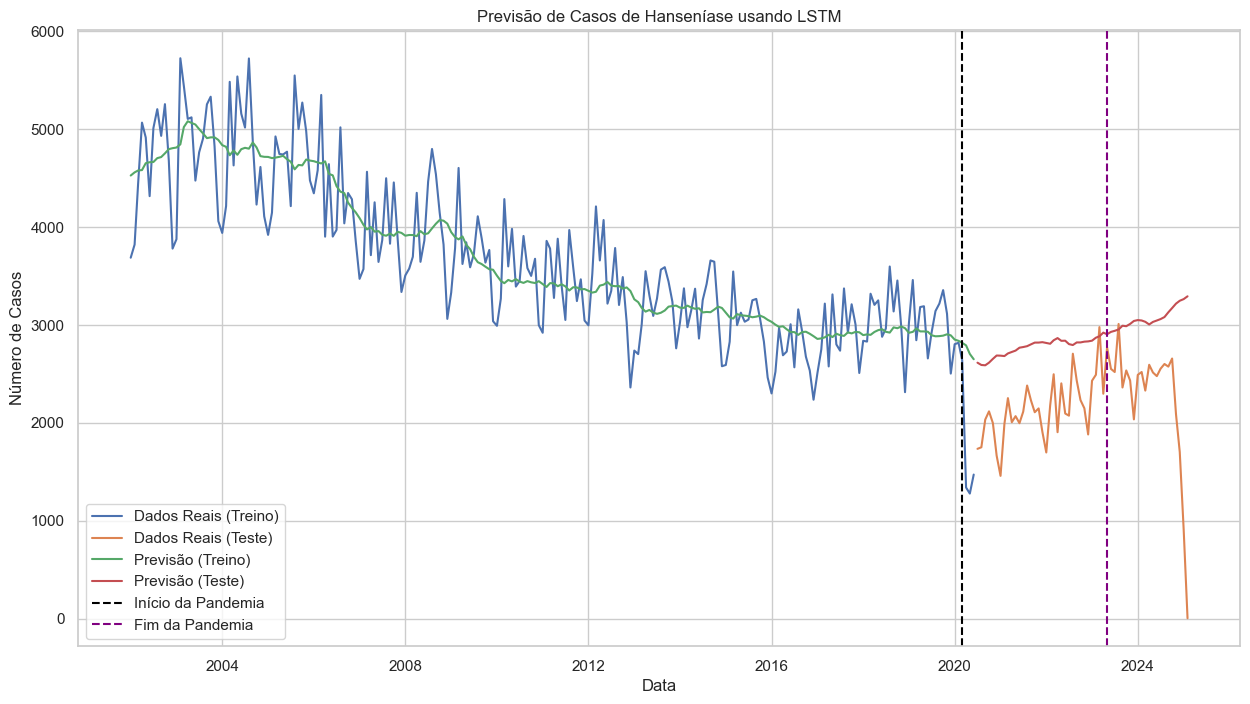

In [105]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Assumindo que df_prophet já está preparado como no exemplo anterior

df = df_dados.copy()

df_prophet = cria_dt_prophet(df)

# Preparar os dados
data = df_prophet[['ds', 'y', 'idade_media', 'lesoes_media', 'nervos_afetados_media', 'doses_recebidas_media']].set_index('ds')

# Normalizar os dados
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Preparar sequências de entrada e saída
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), :])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 12  # Usar 12 meses de histórico para prever o próximo mês
X, y = create_sequences(scaled_data, seq_length)

# Dividir em conjuntos de treino e teste
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Criar e treinar o modelo LSTM
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# Fazer previsões
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverter a normalização
train_predict = scaler.inverse_transform(np.column_stack((train_predict, np.zeros((len(train_predict), 4)))))[:, 0]
test_predict = scaler.inverse_transform(np.column_stack((test_predict, np.zeros((len(test_predict), 4)))))[:, 0]
y_train = scaler.inverse_transform(np.column_stack((y_train.reshape(-1, 1), np.zeros((len(y_train), 4)))))[:, 0]
y_test = scaler.inverse_transform(np.column_stack((y_test.reshape(-1, 1), np.zeros((len(y_test), 4)))))[:, 0]

# Plotar resultados
plt.figure(figsize=(15, 8))
plt.plot(data.index[seq_length:train_size+seq_length], y_train, label='Dados Reais (Treino)')
plt.plot(data.index[train_size+seq_length:], y_test, label='Dados Reais (Teste)')
plt.plot(data.index[seq_length:train_size+seq_length], train_predict, label='Previsão (Treino)')
plt.plot(data.index[train_size+seq_length:], test_predict, label='Previsão (Teste)')
# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")
plt.title('Previsão de Casos de Hanseníase usando LSTM')
plt.xlabel('Data')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True)
plt.show()


#### LSTM II

Epoch 0: Loss = 1.0008646249771118
Epoch 100: Loss = 0.13189691305160522
Epoch 200: Loss = 0.028121529147028923
Epoch 300: Loss = 0.01925186812877655
Epoch 400: Loss = 0.019687535241246223
Epoch 500: Loss = 0.015902794897556305
Epoch 600: Loss = 0.016787709668278694
Early stopping na época 611


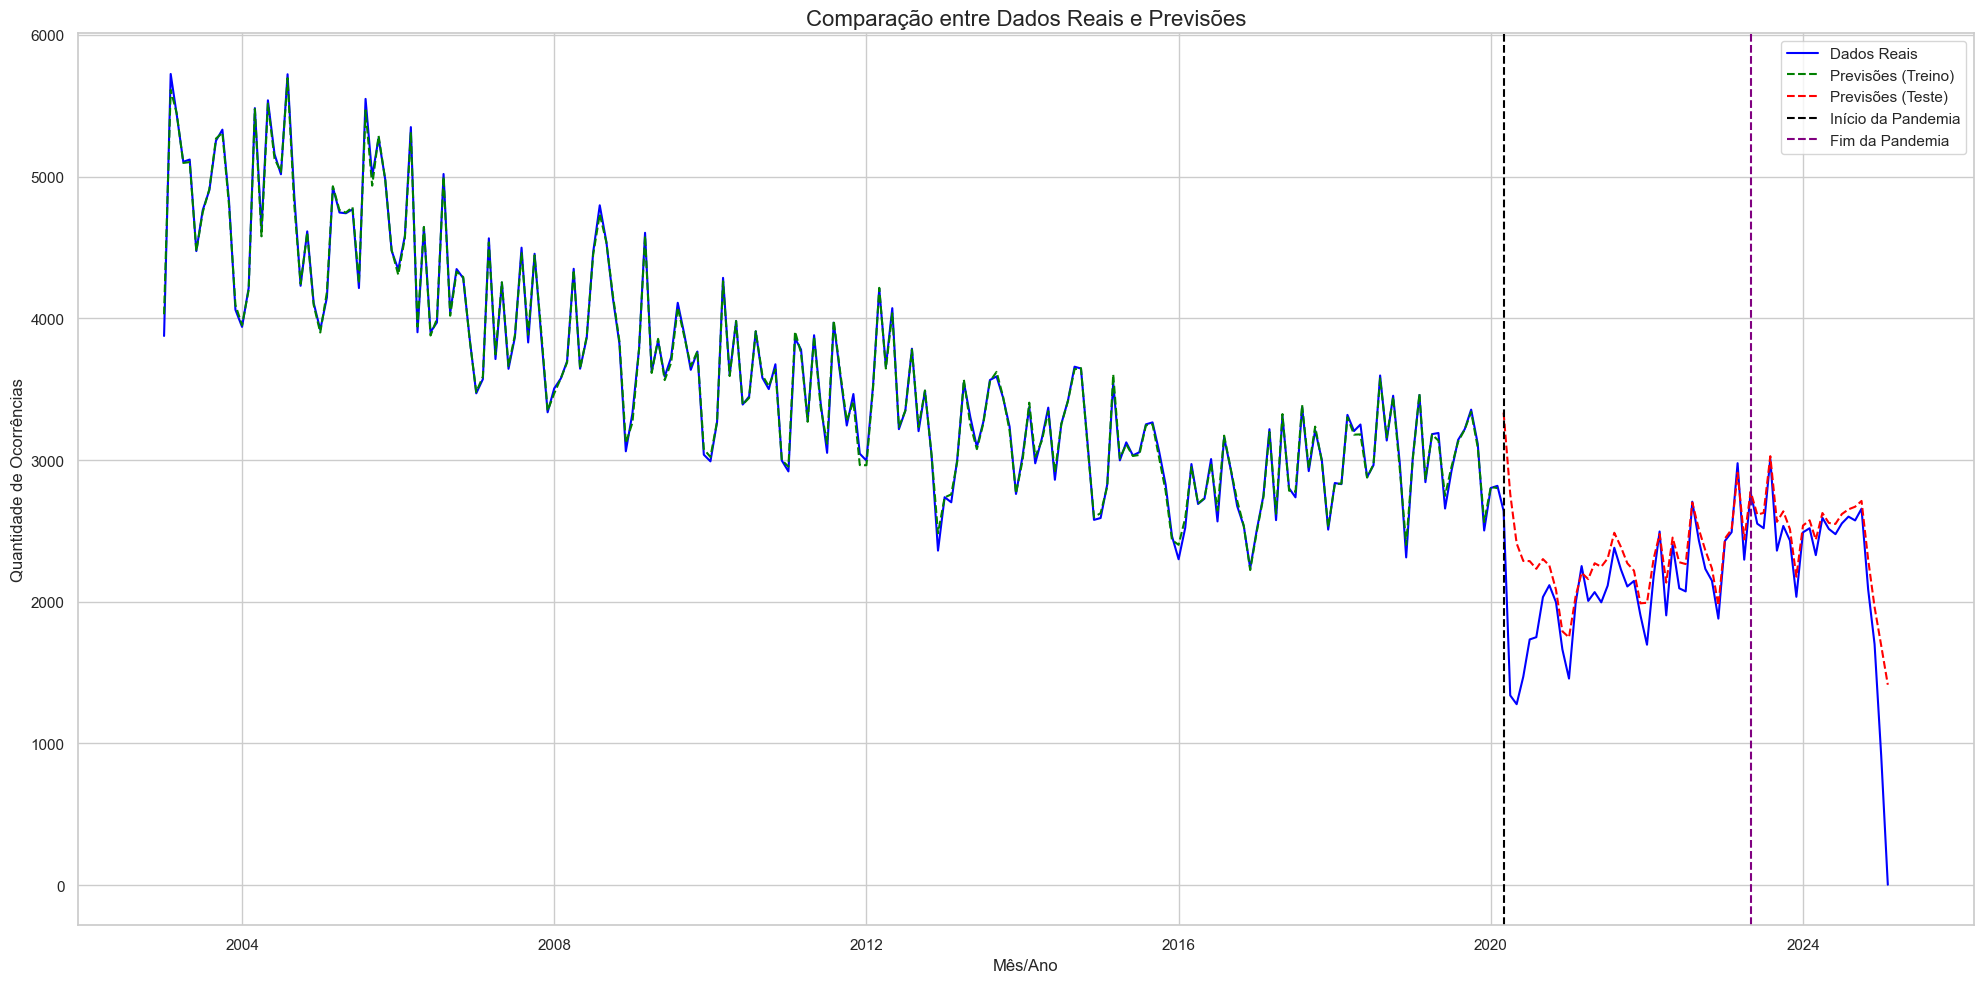

In [106]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

dados_agrupados = cria_dados_agrupados(df_dados)
# Preparação dos Dados
dados_agrupados["ANO_MES"] = pd.to_datetime(dados_agrupados["ANO_MES"], format='%Y-%m')
dados_agrupados["ANO_MES_NUM"] = dados_agrupados["ANO_MES"].map(lambda x: x.toordinal())

# Engenharia de recursos com foco em sazonalidade
dados_agrupados["LAG_1"] = dados_agrupados["quantidade"].shift(1)
dados_agrupados["LAG_2"] = dados_agrupados["quantidade"].shift(2)
dados_agrupados["LAG_3"] = dados_agrupados["quantidade"].shift(3)
dados_agrupados["LAG_6"] = dados_agrupados["quantidade"].shift(6)
dados_agrupados["LAG_12"] = dados_agrupados["quantidade"].shift(12)
dados_agrupados["LAG_24"] = dados_agrupados["quantidade"].shift(24)  # Capturar padrão de 2 anos
dados_agrupados["MEDIA_MOVEL_3"] = dados_agrupados["quantidade"].rolling(window=3).mean()
dados_agrupados["MEDIA_MOVEL_6"] = dados_agrupados["quantidade"].rolling(window=6).mean()
dados_agrupados["MEDIA_MOVEL_12"] = dados_agrupados["quantidade"].rolling(window=12).mean()
dados_agrupados["DIFF"] = dados_agrupados["quantidade"].diff()
dados_agrupados["DIFF_12"] = dados_agrupados["quantidade"].diff(12)  # Diferença anual
dados_agrupados["MES"] = dados_agrupados["ANO_MES"].dt.month
dados_agrupados["SEN_MES"] = np.sin(2 * np.pi * dados_agrupados["MES"]/12)  # Componente sazonal
dados_agrupados["COS_MES"] = np.cos(2 * np.pi * dados_agrupados["MES"]/12)  # Componente sazonal
dados_agrupados["TRIMESTRE"] = dados_agrupados["ANO_MES"].dt.quarter
dados_agrupados["TENDENCIA"] = np.arange(len(dados_agrupados))
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].dt.year

# Remover valores NaN gerados pelos lags e outros cálculos
dados_agrupados.dropna(inplace=True)

# Separar dados de treino e teste
limite_pandemia = pd.to_datetime("2020-03").toordinal()
mask_treino = dados_agrupados["ANO_MES_NUM"] < limite_pandemia
mask_teste = dados_agrupados["ANO_MES_NUM"] >= limite_pandemia

dados_treino = dados_agrupados[mask_treino]
dados_teste = dados_agrupados[mask_teste]

# Selecionar features
features = ["ANO_MES_NUM", "LAG_1", "LAG_2", "LAG_3", "LAG_6", "LAG_12", "LAG_24",
            "MEDIA_MOVEL_3", "MEDIA_MOVEL_6", "MEDIA_MOVEL_12", "DIFF", "DIFF_12",
            "MES", "SEN_MES", "COS_MES", "TRIMESTRE", "TENDENCIA", "ANO"]

X_treino = dados_treino[features].values
y_treino = dados_treino["quantidade"].values.reshape(-1, 1)

X_teste = dados_teste[features].values
y_teste = dados_teste["quantidade"].values.reshape(-1, 1)

# Usar StandardScaler em vez de MinMaxScaler para lidar melhor com outliers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_treino_scaled = scaler_X.fit_transform(X_treino)
y_treino_scaled = scaler_y.fit_transform(y_treino)

X_teste_scaled = scaler_X.transform(X_teste)
y_teste_scaled = scaler_y.transform(y_teste)

# Modelo LSTM para capturar dependências temporais
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(ModeloLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        # Adicionar dimensão de batch e sequência para LSTM
        x = x.unsqueeze(0)
        out, _ = self.lstm(x)
        out = out.squeeze(0)
        out = torch.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Instanciar o modelo
input_size = X_treino_scaled.shape[1]
modelo = ModeloLSTM(input_size)
criterio = nn.MSELoss()
otimizador = optim.Adam(modelo.parameters(), lr=0.0005, weight_decay=1e-5)

# Treinamento com learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(otimizador, 'min', patience=20, factor=0.5)
modelo.train()
melhor_perda = float('inf')
paciencia = 100
contador = 0

for epoch in range(5000):
    inputs = torch.tensor(X_treino_scaled, dtype=torch.float32)
    outputs = torch.tensor(y_treino_scaled, dtype=torch.float32)
    
    otimizador.zero_grad()
    previsoes = modelo(inputs).squeeze()
    perda = criterio(previsoes, outputs.squeeze())
    perda.backward()
    otimizador.step()
    
    scheduler.step(perda)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {perda.item()}")
    
    # Early stopping
    if perda.item() < melhor_perda:
        melhor_perda = perda.item()
        contador = 0
        torch.save(modelo.state_dict(), './modelo/melhor_modelo.pth')
    else:
        contador += 1
        if contador >= paciencia:
            print(f"Early stopping na época {epoch}")
            break

# Carregar o melhor modelo
modelo.load_state_dict(torch.load('./modelo/melhor_modelo.pth'))

# Avaliação
modelo.eval()
with torch.no_grad():
    y_pred_treino_scaled = modelo(torch.tensor(X_treino_scaled, dtype=torch.float32))
    y_pred_teste_scaled = modelo(torch.tensor(X_teste_scaled, dtype=torch.float32))

y_pred_treino = scaler_y.inverse_transform(y_pred_treino_scaled.numpy())
y_pred_teste = scaler_y.inverse_transform(y_pred_teste_scaled.numpy())

# Plotar resultados
plt.figure(figsize=(20, 10))
plt.plot(dados_agrupados["ANO_MES"], dados_agrupados["quantidade"], label="Dados Reais", color='blue')
plt.plot(dados_treino["ANO_MES"], y_pred_treino, label="Previsões (Treino)", color='green', linestyle='--')
plt.plot(dados_teste["ANO_MES"], y_pred_teste, label="Previsões (Teste)", color='red', linestyle='--')
# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")
plt.title("Comparação entre Dados Reais e Previsões", fontsize=16)
plt.xlabel("Mês/Ano")
plt.ylabel("Quantidade de Ocorrências")
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()

#### LSTM III Usando Pytorch

Usando dispositivo: cpu
Época [10/200], Perda Treino: 0.0081, Perda Teste: 0.0080
Época [20/200], Perda Treino: 0.0061, Perda Teste: 0.0074
Época [30/200], Perda Treino: 0.0065, Perda Teste: 0.0070
Época [40/200], Perda Treino: 0.0063, Perda Teste: 0.0069
Época [50/200], Perda Treino: 0.0069, Perda Teste: 0.0071
Época [60/200], Perda Treino: 0.0061, Perda Teste: 0.0073
Época [70/200], Perda Treino: 0.0065, Perda Teste: 0.0086
Época [80/200], Perda Treino: 0.0068, Perda Teste: 0.0070
Época [90/200], Perda Treino: 0.0069, Perda Teste: 0.0074
Época [100/200], Perda Treino: 0.0064, Perda Teste: 0.0075
Época [110/200], Perda Treino: 0.0069, Perda Teste: 0.0075
Época [120/200], Perda Treino: 0.0057, Perda Teste: 0.0068
Época [130/200], Perda Treino: 0.0062, Perda Teste: 0.0075
Época [140/200], Perda Treino: 0.0062, Perda Teste: 0.0070
Época [150/200], Perda Treino: 0.0060, Perda Teste: 0.0069
Época [160/200], Perda Treino: 0.0059, Perda Teste: 0.0074
Época [170/200], Perda Treino: 0.0058, Pe

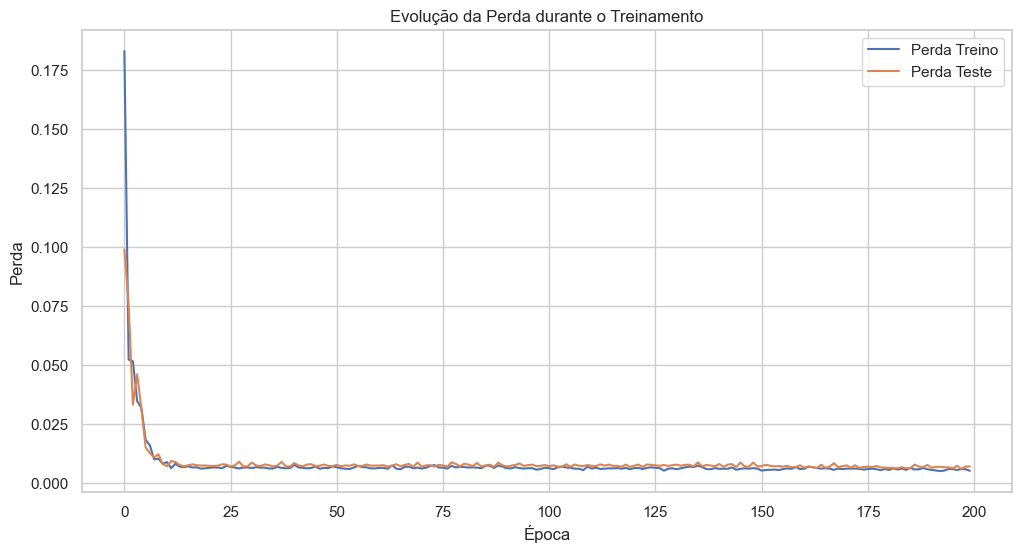

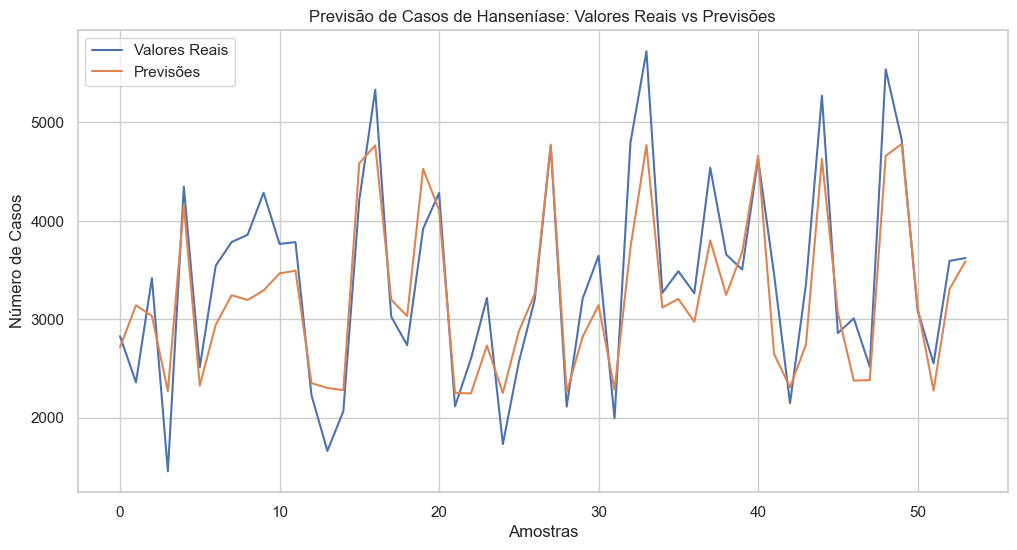

MSE: 227527.4435
RMSE: 476.9984
MAE: 389.7236


In [107]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Verificar se CUDA está disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# Preparar os dados

df = df_dados.copy()

# Assumindo que a função cria_dt_prophet existe e retorna um DataFrame com colunas 'ds' e 'y'
df_prophet = cria_dt_prophet(df)
df_prophet = df_prophet.sort_values('ds')
data = df_prophet[['y', 'idade_media', 'lesoes_media', 'nervos_afetados_media', 'doses_recebidas_media']].values

# Normalizar os dados
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Preparar sequências de entrada e saída
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), :])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 24  # Aumentado para capturar mais contexto temporal
X, y = create_sequences(scaled_data, seq_length)

# Dividir em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Converter para tensores PyTorch
X_train = torch.FloatTensor(X_train).to(device)
y_train = torch.FloatTensor(y_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_test = torch.FloatTensor(y_test).to(device)

# Criar DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Definir modelo LSTM
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Hiperparâmetros
input_size = 5
hidden_size = 128
num_layers = 2
output_size = 1
num_epochs = 200
learning_rate = 0.001

# Inicializar modelo
model = LSTM(input_size, hidden_size, num_layers, output_size).to(device)

# Definir função de perda e otimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Treinar o modelo
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)
            test_loss += loss.item()
    
    train_losses.append(train_loss / len(train_loader))
    test_losses.append(test_loss / len(test_loader))
    
    if (epoch + 1) % 10 == 0:
        print(f'Época [{epoch+1}/{num_epochs}], Perda Treino: {train_losses[-1]:.4f}, Perda Teste: {test_losses[-1]:.4f}')

# Plotar resultados
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Perda Treino')
plt.plot(test_losses, label='Perda Teste')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda durante o Treinamento')
plt.legend()
plt.show()

# Fazer previsões
model.eval()
with torch.no_grad():
    test_predictions = model(X_test).cpu().numpy()

# Inverter a normalização
test_predictions = scaler.inverse_transform(np.column_stack((test_predictions, np.zeros((len(test_predictions), 4)))))[:, 0]
y_test_actual = scaler.inverse_transform(np.column_stack((y_test.cpu().numpy().reshape(-1, 1), np.zeros((len(y_test), 4)))))[:, 0]

# Plotar previsões vs valores reais
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Valores Reais')
plt.plot(test_predictions, label='Previsões')
plt.xlabel('Amostras')
plt.ylabel('Número de Casos')
plt.title('Previsão de Casos de Hanseníase: Valores Reais vs Previsões')
plt.legend()
plt.show()

# Calcular métricas de desempenho
mse = np.mean((y_test_actual - test_predictions)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_actual - test_predictions))
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')


#### Modelo de Rede Neural mais complexo

Epoch 0: Loss = 0.29009371995925903
Epoch 100: Loss = 0.023351572453975677
Epoch 200: Loss = 0.011482295580208302
Epoch 300: Loss = 0.007178373634815216
Epoch 400: Loss = 0.007243518251925707
Epoch 500: Loss = 0.00569204892963171
Epoch 600: Loss = 0.004537038505077362
Epoch 700: Loss = 0.004097213502973318
Epoch 800: Loss = 0.004549209028482437
Early stopping na época 877
MSE no conjunto de treino: 9933.2744140625
MSE no conjunto de teste: 293230.3125


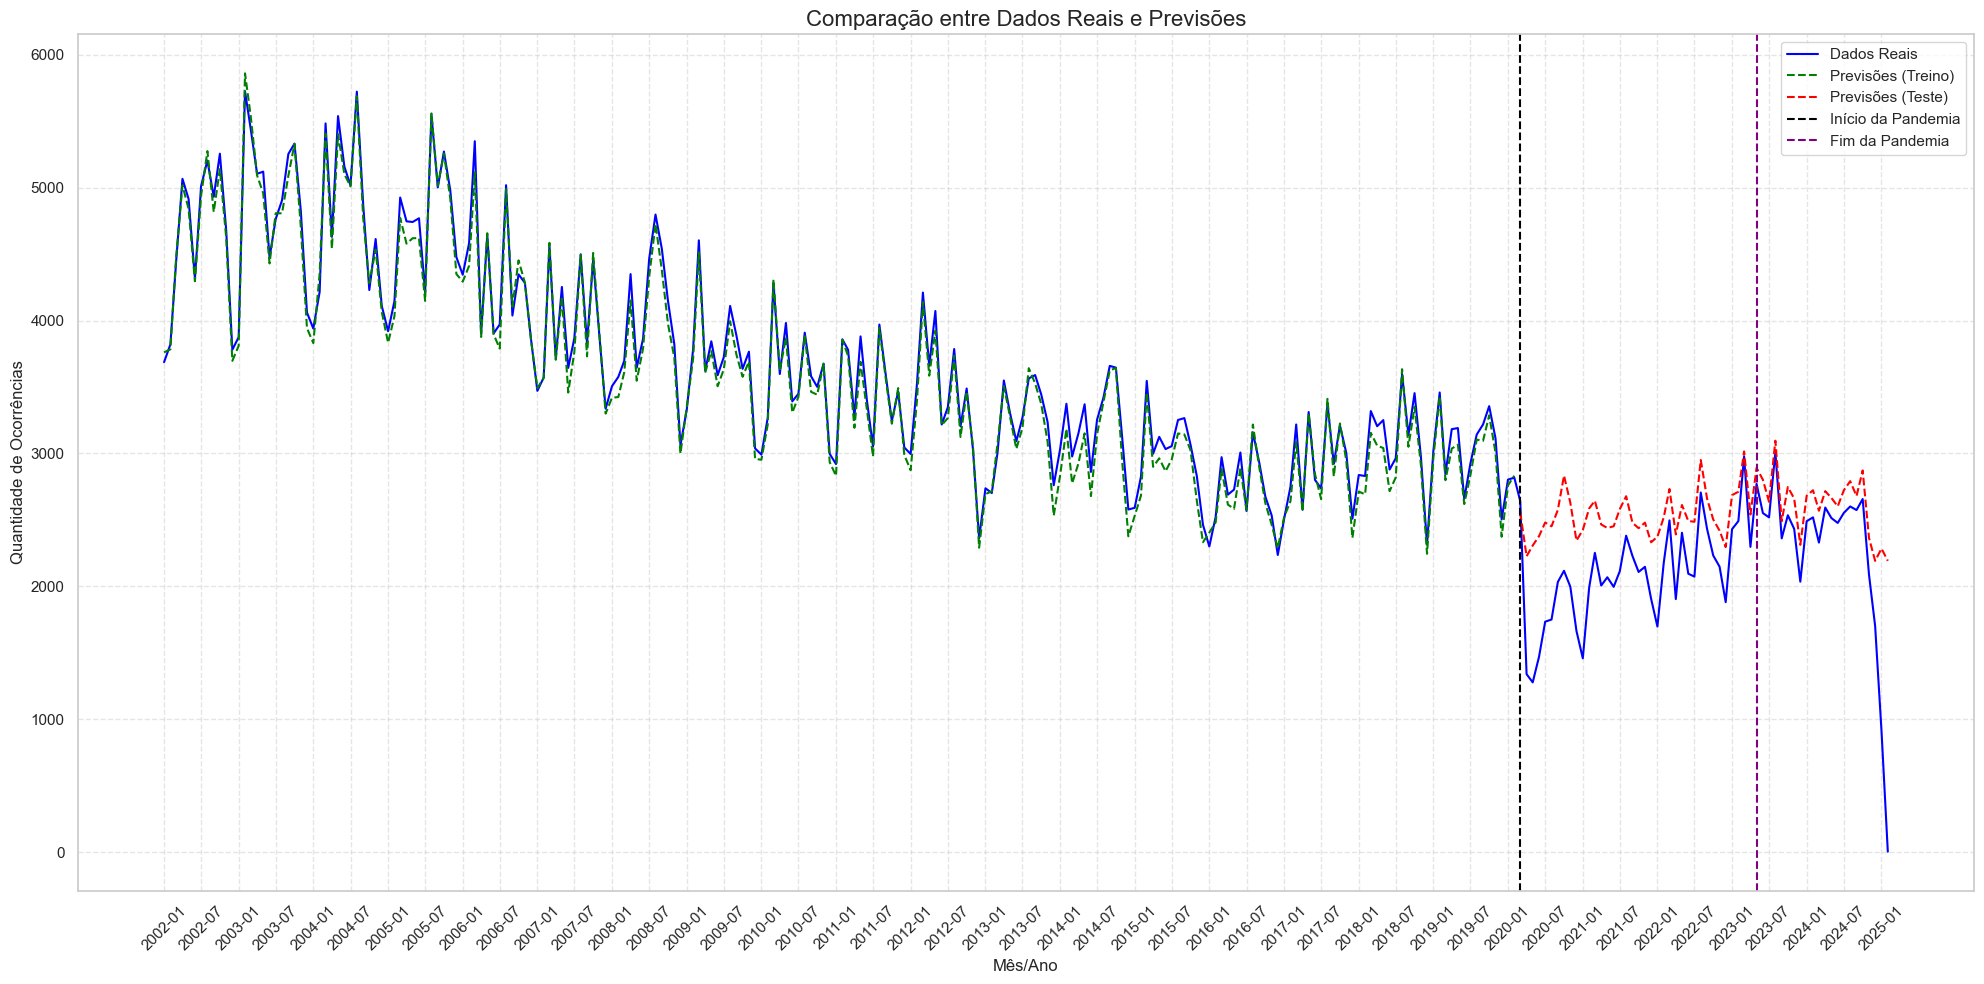

In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

dados_agrupados = cria_dados_agrupados(df_dados)

# Preparação dos Dados
dados_agrupados["ANO_MES"] = pd.to_datetime(dados_agrupados["ANO_MES"], format='%Y-%m')
dados_agrupados["ANO_MES_NUM"] = dados_agrupados["ANO_MES"].map(lambda x: x.toordinal())

# Engenharia de recursos mais robusta
dados_agrupados["LAG_1"] = dados_agrupados["quantidade"].shift(1)
dados_agrupados["LAG_2"] = dados_agrupados["quantidade"].shift(2)
dados_agrupados["LAG_3"] = dados_agrupados["quantidade"].shift(3)
dados_agrupados["LAG_6"] = dados_agrupados["quantidade"].shift(6)
dados_agrupados["LAG_12"] = dados_agrupados["quantidade"].shift(12)
dados_agrupados["MEDIA_MOVEL_3"] = dados_agrupados["quantidade"].rolling(window=3).mean()
dados_agrupados["MEDIA_MOVEL_6"] = dados_agrupados["quantidade"].rolling(window=6).mean()
dados_agrupados["DIFF"] = dados_agrupados["quantidade"].diff()
dados_agrupados["DIFF_2"] = dados_agrupados["quantidade"].diff(2)
dados_agrupados["MES"] = dados_agrupados["ANO_MES"].dt.month
dados_agrupados["TRIMESTRE"] = dados_agrupados["ANO_MES"].dt.quarter
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].dt.year
dados_agrupados["TENDENCIA"] = np.arange(len(dados_agrupados))

# Remover valores NaN gerados pelos lags e outros cálculos
dados_agrupados.dropna(inplace=True)

# Separar dados de treino e teste
limite_pandemia = pd.to_datetime("2020-03").toordinal()
mask_treino = dados_agrupados["ANO_MES_NUM"] < limite_pandemia
mask_teste = dados_agrupados["ANO_MES_NUM"] >= limite_pandemia

dados_treino = dados_agrupados[mask_treino]
dados_teste = dados_agrupados[mask_teste]

# Usar mais features para capturar padrões complexos
X_treino = dados_treino[["ANO_MES_NUM", "LAG_1", "LAG_2", "LAG_3", "LAG_6", "LAG_12", 
                         "MEDIA_MOVEL_3", "MEDIA_MOVEL_6", "DIFF", "DIFF_2", "MES", 
                         "TRIMESTRE", "ANO", "TENDENCIA"]].values
y_treino = dados_treino["quantidade"].values.reshape(-1, 1)

X_teste = dados_teste[["ANO_MES_NUM", "LAG_1", "LAG_2", "LAG_3", "LAG_6", "LAG_12", 
                       "MEDIA_MOVEL_3", "MEDIA_MOVEL_6", "DIFF", "DIFF_2", "MES", 
                       "TRIMESTRE", "ANO", "TENDENCIA"]].values
y_teste = dados_teste["quantidade"].values.reshape(-1, 1)

# Escalonamento dos dados - usando StandardScaler para melhor generalização
scaler_X = StandardScaler()
scaler_y = MinMaxScaler()

X_treino_scaled = scaler_X.fit_transform(X_treino)
y_treino_scaled = scaler_y.fit_transform(y_treino)

X_teste_scaled = scaler_X.transform(X_teste)
y_teste_scaled = scaler_y.transform(y_teste)

# Modelo de Rede Neural mais complexo
class ModeloNN(nn.Module):
    def __init__(self, input_size):
        super(ModeloNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Instanciar o modelo com o número correto de features
input_size = X_treino_scaled.shape[1]
modelo = ModeloNN(input_size)
criterio = nn.MSELoss()
otimizador = optim.Adam(modelo.parameters(), lr=0.0001, weight_decay=1e-5)

# Treinamento com early stopping
modelo.train()
melhor_perda = float('inf')
paciencia = 100
contador = 0
historico_perda = []

for epoch in range(5000):  # Aumentar número de épocas
    inputs = torch.tensor(X_treino_scaled, dtype=torch.float32)
    outputs = torch.tensor(y_treino_scaled, dtype=torch.float32)
    
    otimizador.zero_grad()
    previsoes = modelo(inputs).squeeze()
    perda = criterio(previsoes, outputs.squeeze())
    perda.backward()
    otimizador.step()
    
    historico_perda.append(perda.item())
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {perda.item()}")
    
    # Early stopping
    if perda.item() < melhor_perda:
        melhor_perda = perda.item()
        contador = 0
        # Salvar o melhor modelo
        torch.save(modelo.state_dict(), 'melhor_modelo.pth')
    else:
        contador += 1
        if contador >= paciencia:
            print(f"Early stopping na época {epoch}")
            break

# Carregar o melhor modelo
modelo.load_state_dict(torch.load('melhor_modelo.pth'))

# Avaliação
modelo.eval()
with torch.no_grad():
    y_pred_treino_scaled = modelo(torch.tensor(X_treino_scaled, dtype=torch.float32))
    y_pred_teste_scaled = modelo(torch.tensor(X_teste_scaled, dtype=torch.float32))

y_pred_treino = scaler_y.inverse_transform(y_pred_treino_scaled.numpy())
y_pred_teste = scaler_y.inverse_transform(y_pred_teste_scaled.numpy())

# Calcular métricas
mse_treino = mean_squared_error(y_treino, y_pred_treino)
mse_teste = mean_squared_error(y_teste, y_pred_teste)
print(f"MSE no conjunto de treino: {mse_treino}")
print(f"MSE no conjunto de teste: {mse_teste}")

# Plotar resultados
plt.figure(figsize=(20, 10))
plt.plot(dados_agrupados["ANO_MES"], dados_agrupados["quantidade"], label="Dados Reais", color='blue')
plt.plot(dados_treino["ANO_MES"], y_pred_treino, label="Previsões (Treino)", color='green', linestyle='--')
plt.plot(dados_teste["ANO_MES"], y_pred_teste, label="Previsões (Teste)", color='red', linestyle='--')

# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")

plt.title("Comparação entre Dados Reais e Previsões", fontsize=16)
plt.xlabel("Mês/Ano")
plt.ylabel("Quantidade de Ocorrências")
xticks = pd.date_range(dados_agrupados["ANO_MES"].min(), dados_agrupados["ANO_MES"].max(), freq="6MS")
plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### ARIMA

d:\python\data_health\venv_health\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\python\data_health\venv_health\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\python\data_health\venv_health\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


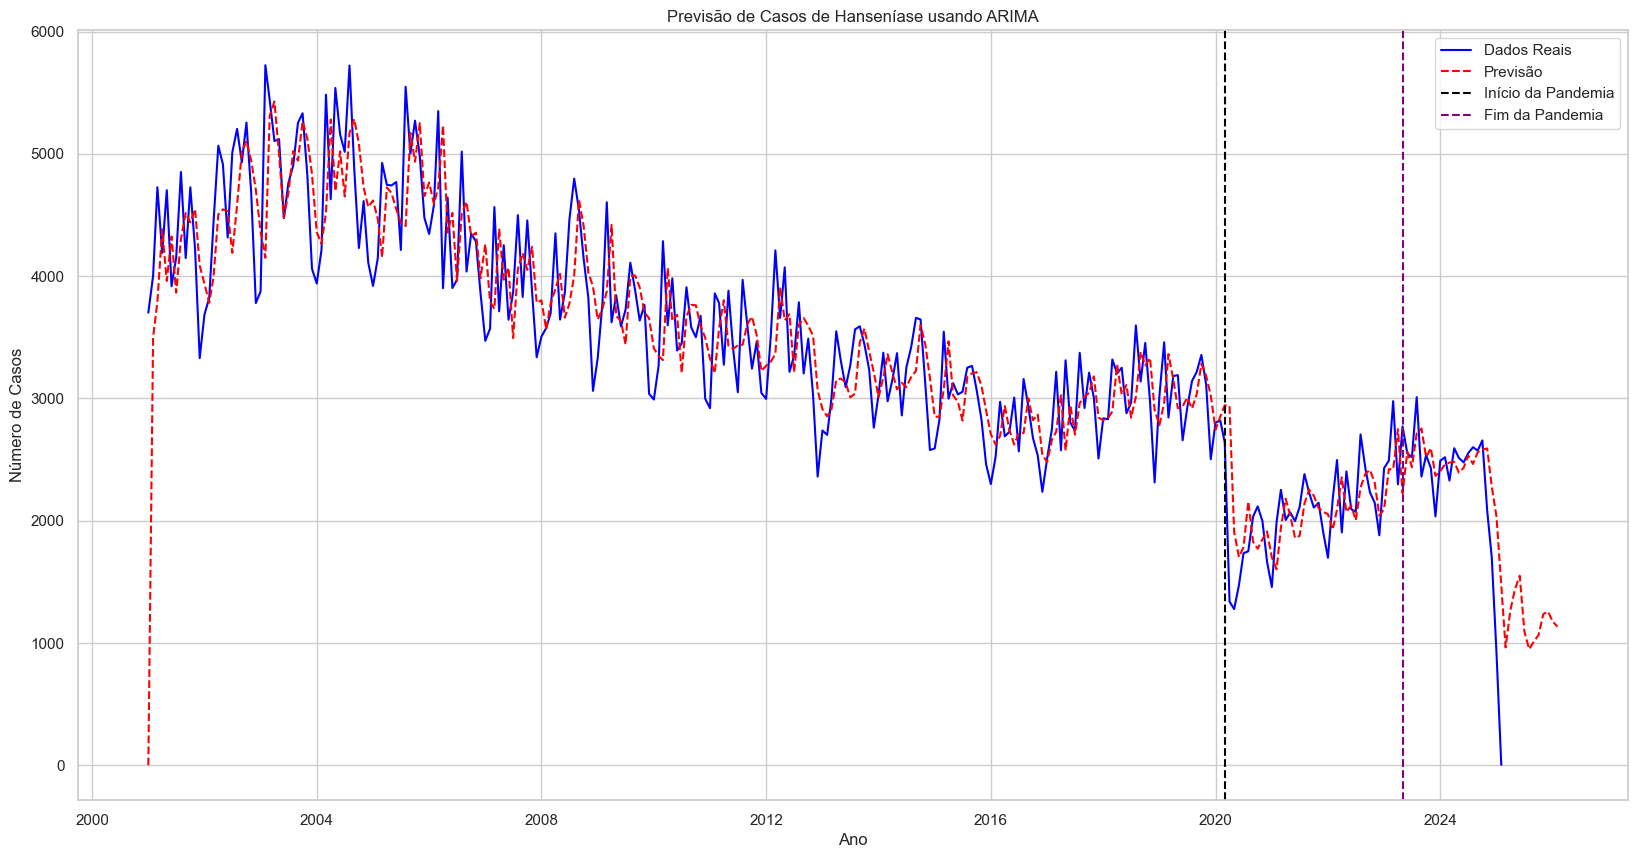

In [109]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

df = df_dados.copy()

df_prophet = cria_dt_prophet(df)

# Preparar os dados
df_arima = df_prophet[['ds', 'y']].set_index('ds')

# Ajustar o modelo ARIMA
model_arima = ARIMA(df_arima, order=(5, 1, 0))  # Parâmetros (p, d, q)
model_arima_fit = model_arima.fit()

# Fazer previsões para todo o período
forecast_arima = model_arima_fit.predict(start=0, end=len(df_arima) + 11)  # Prever até 12 passos à frente

# Plotar resultados
plt.figure(figsize=(20, 10))
plt.plot(df_arima.index, df_arima['y'], label='Dados Reais', color='blue')
plt.plot(forecast_arima.index, forecast_arima.values, label='Previsão', linestyle='--', color='red')
# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")

plt.title('Previsão de Casos de Hanseníase usando ARIMA')
plt.xlabel('Ano')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True)
plt.show()


### SARIMA 

d:\python\data_health\venv_health\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\python\data_health\venv_health\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


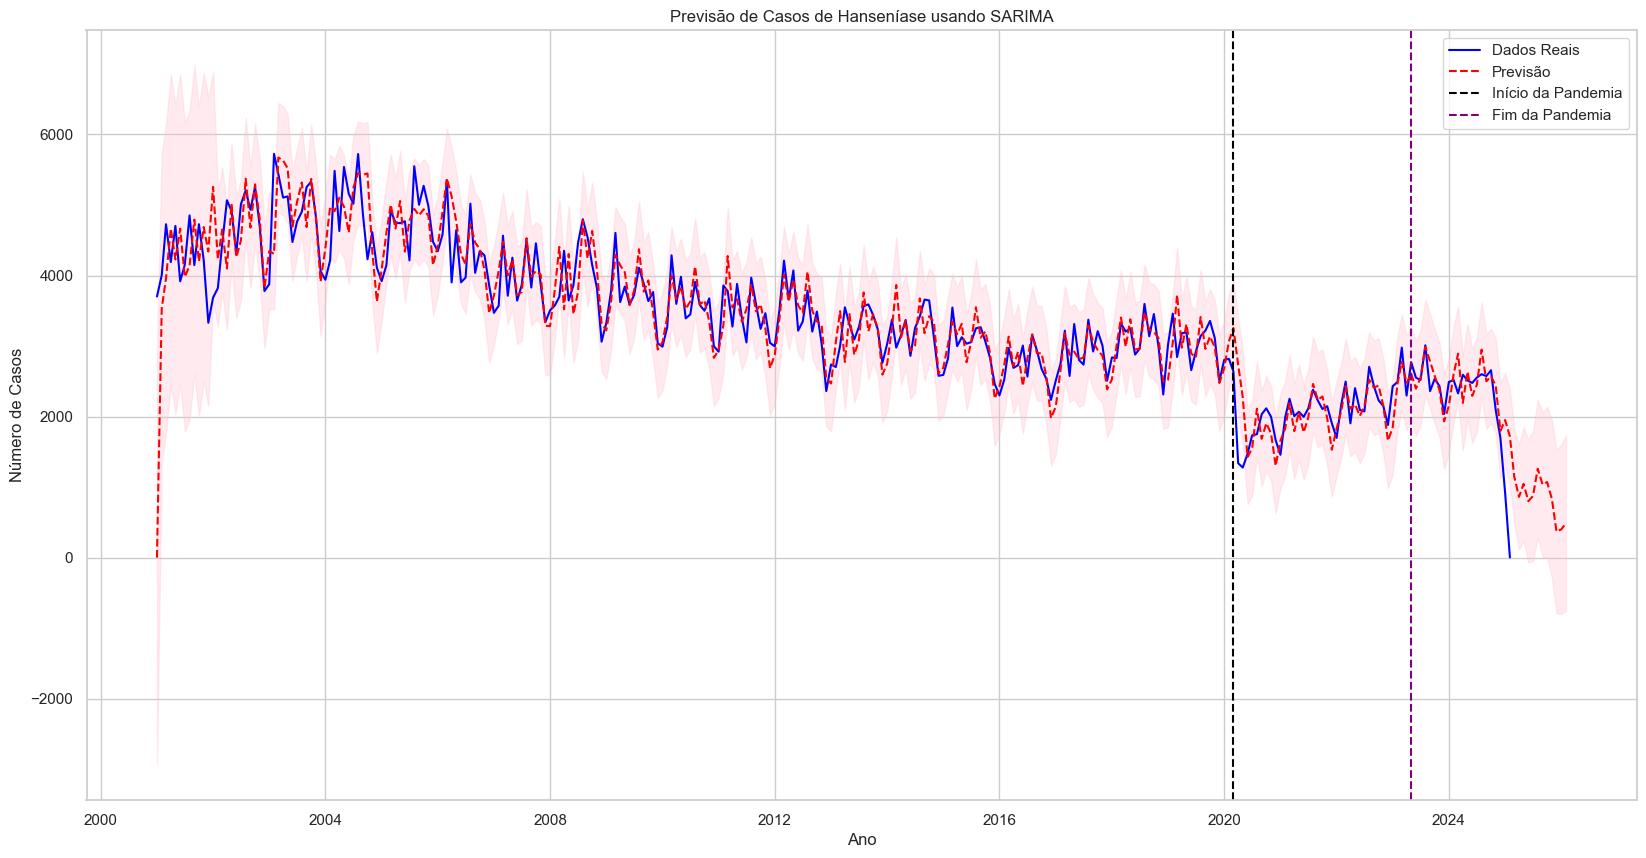

In [110]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

df = df_dados.copy()

df_prophet = cria_dt_prophet(df)

# Ajustar o modelo SARIMA
model_sarima = SARIMAX(df_arima['y'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_sarima_fit = model_sarima.fit()

# Fazer previsões para todo o período
forecast_sarima = model_sarima_fit.get_prediction(start=0, end=len(df_arima) + 11)
forecast_sarima_mean = forecast_sarima.predicted_mean
forecast_sarima_ci = forecast_sarima.conf_int()

# Plotar resultados
plt.figure(figsize=(20, 10))
plt.plot(df_arima.index, df_arima['y'], label='Dados Reais', color='blue')
plt.plot(forecast_sarima_mean.index, forecast_sarima_mean.values, label='Previsão', linestyle='--', color='red')
plt.fill_between(forecast_sarima_ci.index,
                 forecast_sarima_ci.iloc[:, 0],
                 forecast_sarima_ci.iloc[:, 1], color='pink', alpha=0.3)
# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")                 
plt.title('Previsão de Casos de Hanseníase usando SARIMA')
plt.xlabel('Ano')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True)
plt.show()


### XGBoost ou LightGBM

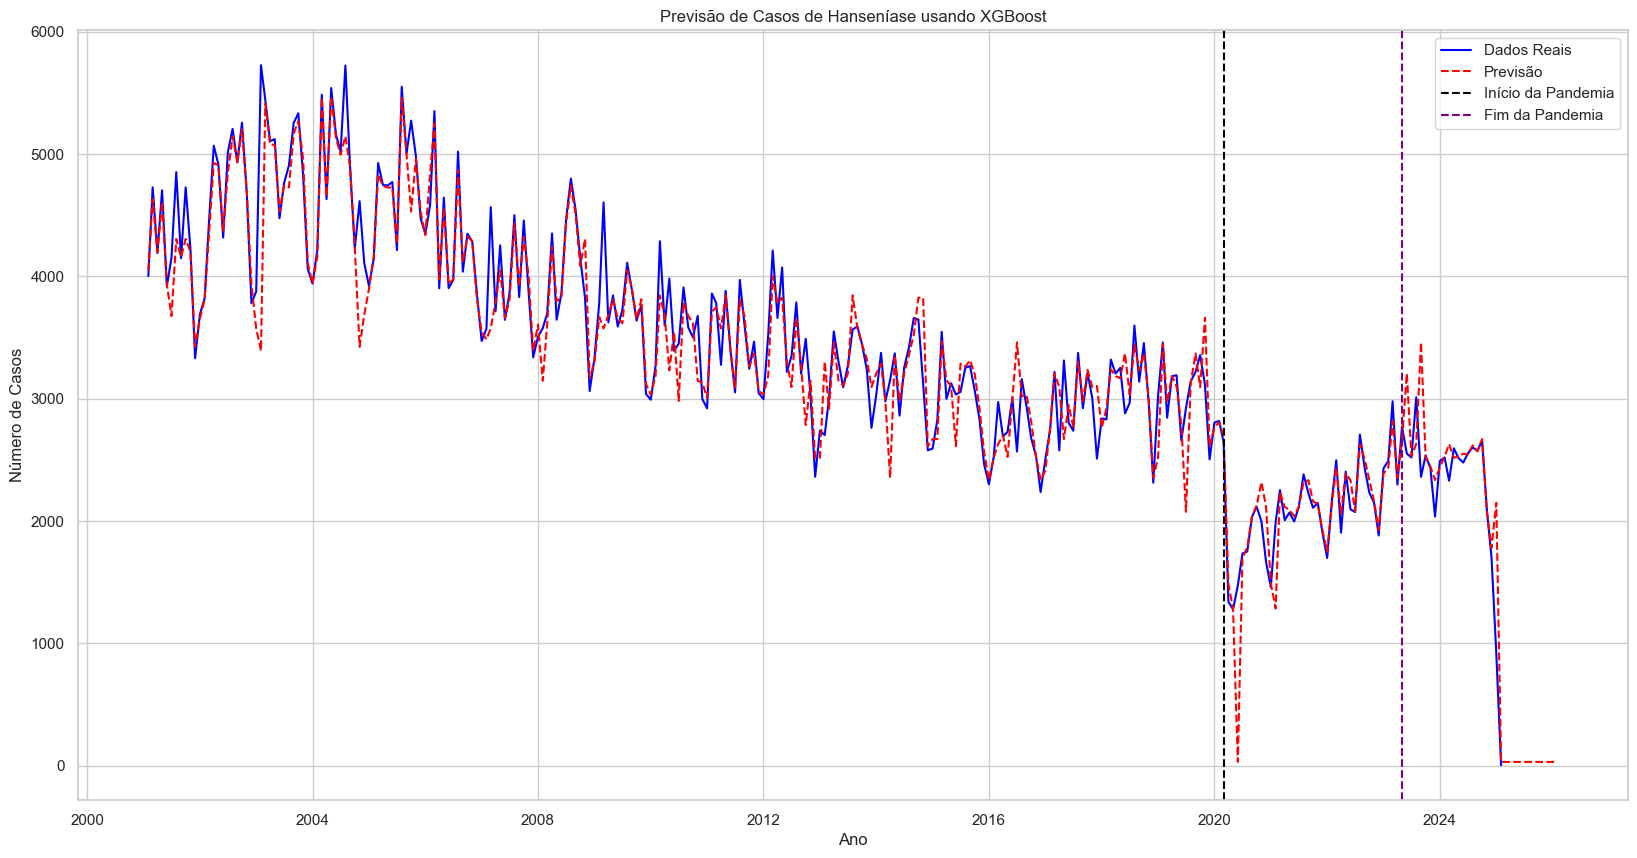

In [111]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = df_dados.copy()

# Assumindo que a função cria_dt_prophet existe e retorna um DataFrame com colunas 'ds' e 'y'
df_prophet = cria_dt_prophet(df)

# Criar variável lag_1 (valor anterior como feature)
df_prophet['lag_1'] = df_prophet['y'].shift(1)
df_prophet.dropna(inplace=True)  # Remove linhas com NaN (primeira linha)

# Dividir em treino e teste
X = df_prophet[['lag_1']]
y = df_prophet['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar o modelo XGBoost
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
model_xgb.fit(X_train, y_train)

# Prever todo o período histórico
df_prophet['Previsão'] = np.nan
for i in range(len(df_prophet)):
    df_prophet.iloc[i, df_prophet.columns.get_loc('Previsão')] = model_xgb.predict([[df_prophet.iloc[i]['lag_1']]])[0]

# Adicionar previsões futuras (12 passos à frente)
last_date = df_prophet['ds'].iloc[-1]
last_pred = df_prophet['Previsão'].iloc[-1]

future_dates = [last_date + pd.DateOffset(months=i+1) for i in range(12)]
future_preds = []
last_value = last_pred

for _ in range(12):
    next_pred = model_xgb.predict([[last_value]])[0]
    future_preds.append(next_pred)
    last_value = next_pred

future_df = pd.DataFrame({
    'ds': future_dates,
    'lag_1': [last_pred] + future_preds[:-1],
    'Previsão': future_preds
})

df_prophet_extended = pd.concat([df_prophet, future_df], ignore_index=True)

# Plotar resultados
plt.figure(figsize=(20, 10))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Dados Reais', color='blue')
plt.plot(df_prophet_extended['ds'], df_prophet_extended['Previsão'], label='Previsão', linestyle='--', color='red')

# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")

plt.title('Previsão de Casos de Hanseníase usando XGBoost')
plt.xlabel('Ano')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True)
plt.show()


Modelo	Melhor Para	Limitações
Prophet	Sazonalidade e tendência simples	Não lida bem com padrões não-lineares complexos
ARIMA	Séries temporais lineares	Não lida bem com sazonalidade
SARIMA	Séries sazonais	Complexidade na escolha dos parâmetros
LSTM	Padrões não-lineares complexos	Exige mais dados e tempo
XGBoost	Séries supervisionadas	Não captura dependências temporais diretamente

### MLP, Random Forest, XGBoost, SVR

#### Preparação dos dados

In [112]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

dados_agrupados = cria_dados_agrupados(df_dados)

# Preparação dos Dados
dados_agrupados["ANO_MES"] = pd.to_datetime(dados_agrupados["ANO_MES"], format='%Y-%m')
dados_agrupados["ANO_MES_NUM"] = dados_agrupados["ANO_MES"].map(lambda x: x.toordinal())

# Adicionar recursos temporais (lags, médias móveis, diferença e indicadores sazonais)
dados_agrupados["LAG_1"] = dados_agrupados["quantidade"].shift(1)
dados_agrupados["LAG_2"] = dados_agrupados["quantidade"].shift(2)
dados_agrupados["LAG_3"] = dados_agrupados["quantidade"].shift(3)
dados_agrupados["MEDIA_MOVEL_3"] = dados_agrupados["quantidade"].rolling(window=3).mean()
dados_agrupados["MEDIA_MOVEL_6"] = dados_agrupados["quantidade"].rolling(window=6).mean()
dados_agrupados["DIFF"] = dados_agrupados["quantidade"].diff()
dados_agrupados["DIFF_2"] = dados_agrupados["quantidade"].diff(2)
dados_agrupados["MES"] = dados_agrupados["ANO_MES"].dt.month
dados_agrupados["TRIMESTRE"] = dados_agrupados["ANO_MES"].dt.quarter

# Remover valores NaN gerados pelos lags e outros cálculos
dados_agrupados.dropna(inplace=True)

# Variáveis independentes e dependentes
X = dados_agrupados[["ANO_MES_NUM", "LAG_1", "LAG_2", "LAG_3", "MEDIA_MOVEL_3", 
                     "MEDIA_MOVEL_6", "DIFF", "DIFF_2", "MES", "TRIMESTRE"]].values
y = dados_agrupados["quantidade"].values

# Escalonamento dos dados
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Separar dados de treino e teste
limite_pandemia = pd.to_datetime("2020-03").toordinal()
mask_treino = X[:, 0] < limite_pandemia
mask_teste = X[:, 0] >= limite_pandemia

X_treino = X_scaled[mask_treino]
y_treino = y_scaled[mask_treino]
X_teste = X_scaled[mask_teste]
y_teste = y_scaled[mask_teste]

# Função para reverter escalonamento
def inverter_escalonamento(y_pred_scaled):
    return scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

#### Modelo 1: Rede Neural Melhorada

In [113]:
# Modelo 1: Rede Neural Melhorada
class ModeloNN(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128, hidden_size3=64):
        super(ModeloNN, self).__init__()
        # Camada de entrada com normalização em lote
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)
        self.dropout1 = nn.Dropout(0.3)
        
        # Camadas intermediárias com conexões residuais
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.bn3 = nn.BatchNorm1d(hidden_size3)
        self.dropout3 = nn.Dropout(0.2)
        
        # Camada de saída
        self.fc4 = nn.Linear(hidden_size3, 1)
        
        # Camada de atenção temporal
        self.attention = nn.Linear(hidden_size3, 1)
        
    def forward(self, x):
        # Camada 1 com ativação LeakyReLU
        x1 = self.fc1(x)
        x1 = self.bn1(x1)
        x1 = F.leaky_relu(x1, 0.1)
        x1 = self.dropout1(x1)
        
        # Camada 2 com ativação LeakyReLU
        x2 = self.fc2(x1)
        x2 = self.bn2(x2)
        x2 = F.leaky_relu(x2, 0.1)
        x2 = self.dropout2(x2)
        
        # Camada 3 com ativação LeakyReLU e conexão residual
        x3 = self.fc3(x2)
        x3 = self.bn3(x3)
        x3 = F.leaky_relu(x3, 0.1)
        x3 = self.dropout3(x3)
        
        # Mecanismo de atenção simplificado
        attention_weights = torch.sigmoid(self.attention(x3))
        x3 = x3 * attention_weights
        
        # Camada de saída
        output = self.fc4(x3)
        return output


# Configuração e treinamento do modelo MLP aprimorado
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_treino.shape[1]
hidden_size1 = 256
hidden_size2 = 128
hidden_size3 = 64
learning_rate = 0.0005  # Taxa de aprendizado reduzida
num_epochs = 5000
weight_decay = 1e-4  # Regularização L2 mais forte
# Instanciar o modelo
modelo_nn = ModeloNN(input_size, hidden_size1, hidden_size2, hidden_size3).to(device)
# Usar otimizador Adam com programação de taxa de aprendizado
criterio = nn.MSELoss()
otimizador = optim.Adam(modelo_nn.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(otimizador, mode='min', factor=0.5, patience=50, verbose=True)

# Dados para GPU
X_tensor_treino = torch.tensor(X_treino, dtype=torch.float32).to(device)
y_tensor_treino = torch.tensor(y_treino, dtype=torch.float32).to(device)

# Implementar early stopping
melhor_perda = float('inf')
paciencia = 100
contador = 0
historico_perda = []

# Treinamento do modelo MLP
modelo_nn.train()
for epoch in range(num_epochs):
    otimizador.zero_grad()
    previsoes_nn = modelo_nn(X_tensor_treino)
    perda_nn = criterio(previsoes_nn, y_tensor_treino)
    perda_nn.backward()
    
    # Clipping de gradiente para estabilidade
    torch.nn.utils.clip_grad_norm_(modelo_nn.parameters(), max_norm=1.0)
    
    otimizador.step()
    historico_perda.append(perda_nn.item())
    
    # Atualizar scheduler
    scheduler.step(perda_nn)
    
    # Early stopping
    if perda_nn.item() < melhor_perda:
        melhor_perda = perda_nn.item()
        contador = 0
        # Salvar o melhor modelo
        torch.save(modelo_nn.state_dict(), './modelo/melhor_modelo.pth')
    else:
        contador += 1
        if contador >= paciencia:
            print(f"Early stopping na época {epoch+1}")
            break
    
    # Imprimir progresso a cada 100 épocas
    if (epoch+1) % 100 == 0:
        print(f'Época [{epoch+1}/{num_epochs}], Perda: {perda_nn.item():.6f}')

# Previsão com MLP
# Carregar o melhor modelo
modelo_nn.load_state_dict(torch.load( './modelo/melhor_modelo.pth'))
modelo_nn.eval()
X_tensor_treino = torch.tensor(X_treino, dtype=torch.float32).to(device)
X_tensor_teste = torch.tensor(X_teste, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_nn_scaled_treino = modelo_nn(X_tensor_treino).cpu().numpy()
    y_pred_nn_scaled_teste = modelo_nn(X_tensor_teste).cpu().numpy()

y_pred_nn_treino = inverter_escalonamento(y_pred_nn_scaled_treino)
y_pred_nn_teste = inverter_escalonamento(y_pred_nn_scaled_teste)

d:\python\data_health\venv_health\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Época [100/5000], Perda: 0.020665
Época [200/5000], Perda: 0.015832
Época [300/5000], Perda: 0.007949
Época [400/5000], Perda: 0.007471
Época [500/5000], Perda: 0.005164
Época [600/5000], Perda: 0.004487
Época [700/5000], Perda: 0.002999
Época [800/5000], Perda: 0.002420
Época [900/5000], Perda: 0.001812
Early stopping na época 994


#### Modelo 2: Random Forest

In [114]:
# Modelo 2: Random Forest
modelo_rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)
modelo_rf.fit(X_treino, y_treino.ravel())

y_pred_rf_scaled_treino = modelo_rf.predict(X_treino)
y_pred_rf_scaled_teste = modelo_rf.predict(X_teste)
y_pred_rf_treino = inverter_escalonamento(y_pred_rf_scaled_treino)
y_pred_rf_teste = inverter_escalonamento(y_pred_rf_scaled_teste)

#### Modelo 3: XGBoost

In [115]:
# Modelo 3: XGBoost
modelo_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=7,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
modelo_xgb.fit(X_treino, y_treino.ravel())

y_pred_xgb_scaled_treino = modelo_xgb.predict(X_treino)
y_pred_xgb_scaled_teste = modelo_xgb.predict(X_teste)
y_pred_xgb_treino = inverter_escalonamento(y_pred_xgb_scaled_treino)
y_pred_xgb_teste = inverter_escalonamento(y_pred_xgb_scaled_teste)

#### Modelo 4: SVR

In [116]:
# Modelo 4: SVR
## Definir os parâmetros para busca
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

# Inicializar o GridSearchCV
grid_search = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Treinar o modelo com os dados de treino
grid_search.fit(X_treino, y_treino.ravel())

# Obter os melhores parâmetros
melhores_params = grid_search.best_params_
print(f"Melhores parâmetros: {melhores_params}")

# Usar o modelo otimizado
modelo_svr = SVR(
    kernel='rbf',
    C=melhores_params['C'],
    epsilon=melhores_params['epsilon'],
    gamma=melhores_params['gamma']
)
modelo_svr.fit(X_treino, y_treino.ravel())

# Fazer previsões
y_pred_svr_scaled_treino = modelo_svr.predict(X_treino)
y_pred_svr_scaled_teste = modelo_svr.predict(X_teste)
y_pred_svr_treino = inverter_escalonamento(y_pred_svr_scaled_treino)
y_pred_svr_teste = inverter_escalonamento(y_pred_svr_scaled_teste)

Fitting 5 folds for each of 125 candidates, totalling 625 fits
Melhores parâmetros: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto'}


#### Comparação de erros, Calculo de MSE e Plotar

Erro Quadrático Médio (MSE):
MLP - Treino: 4915.6567, Teste: 150023.9375
Random Forest - Treino: 2607.7843, Teste: 455131.7647
XGBoost - Treino: 472.6731, Teste: 497461.0312
SVR - Treino: 979.2074, Teste: 28687.1887


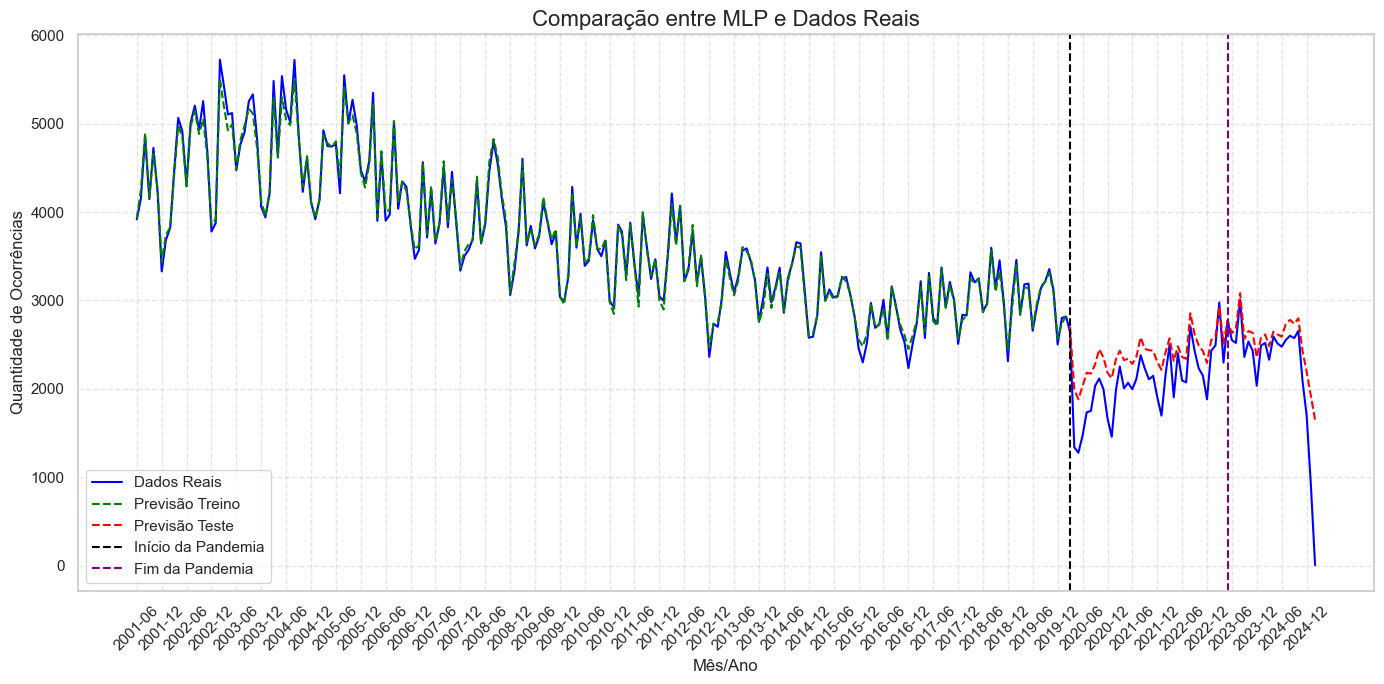

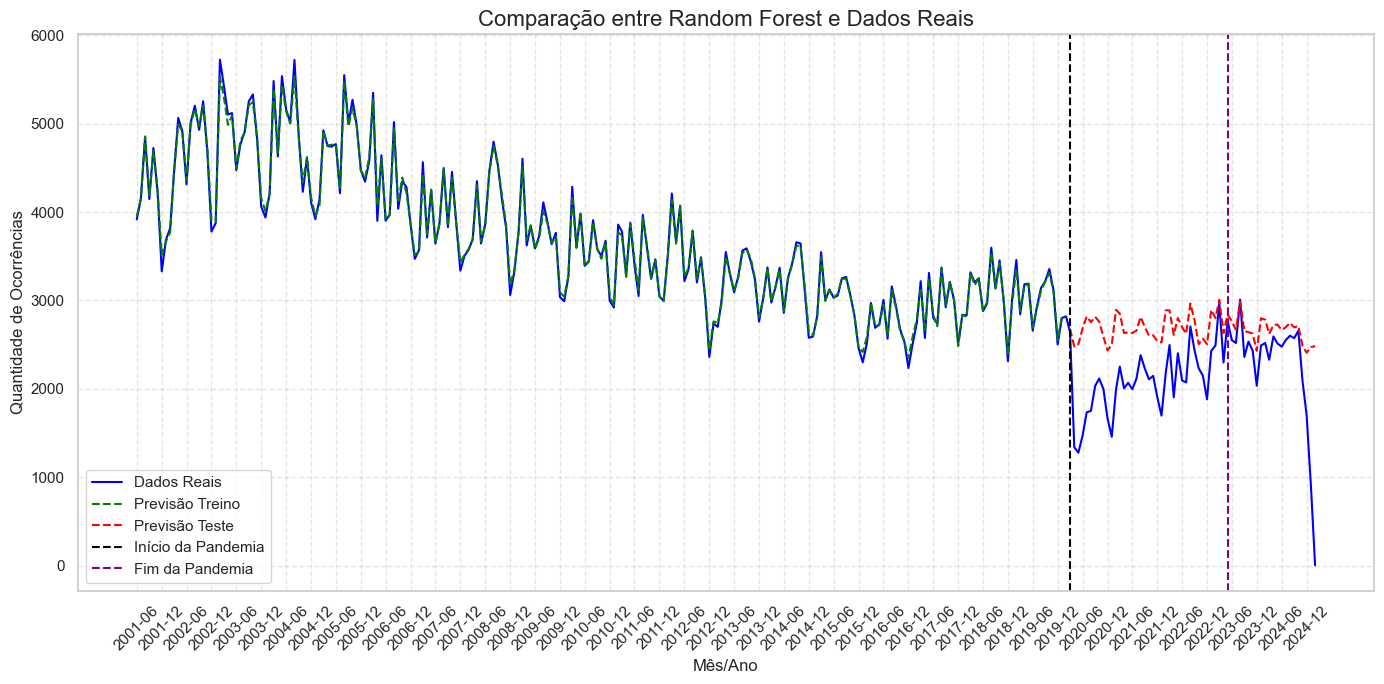

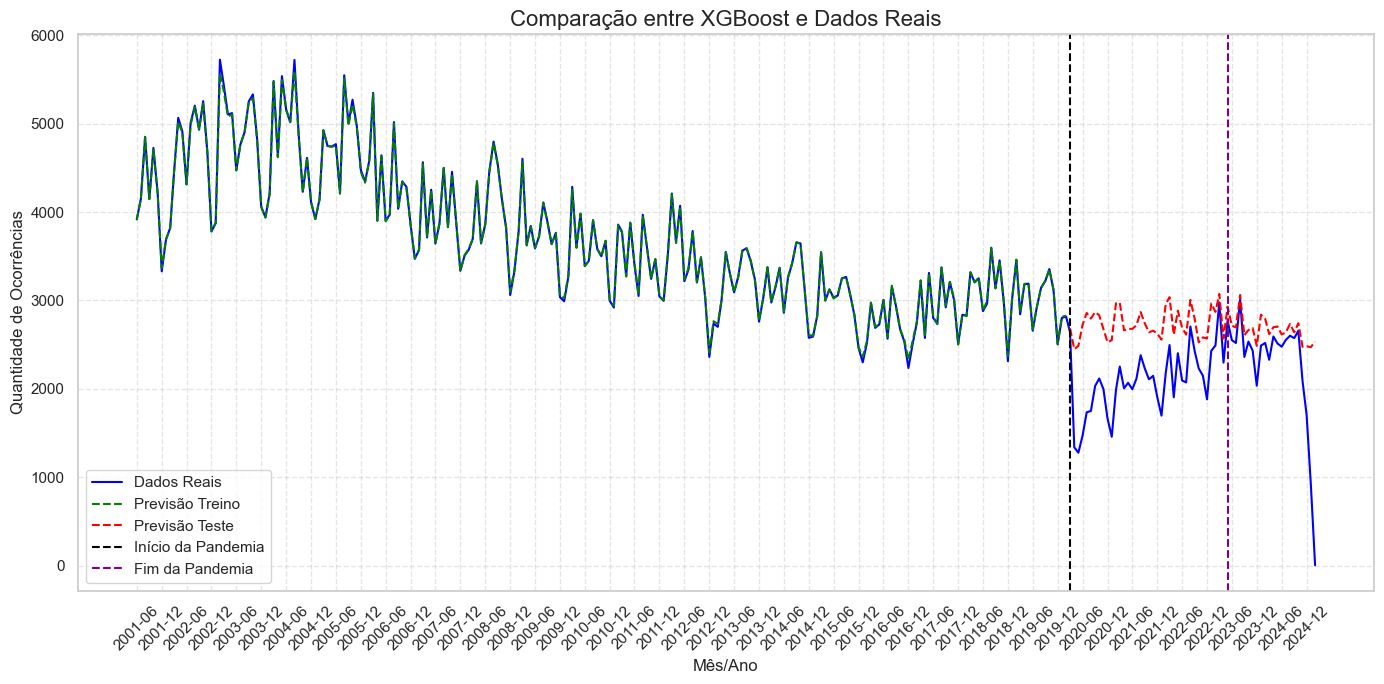

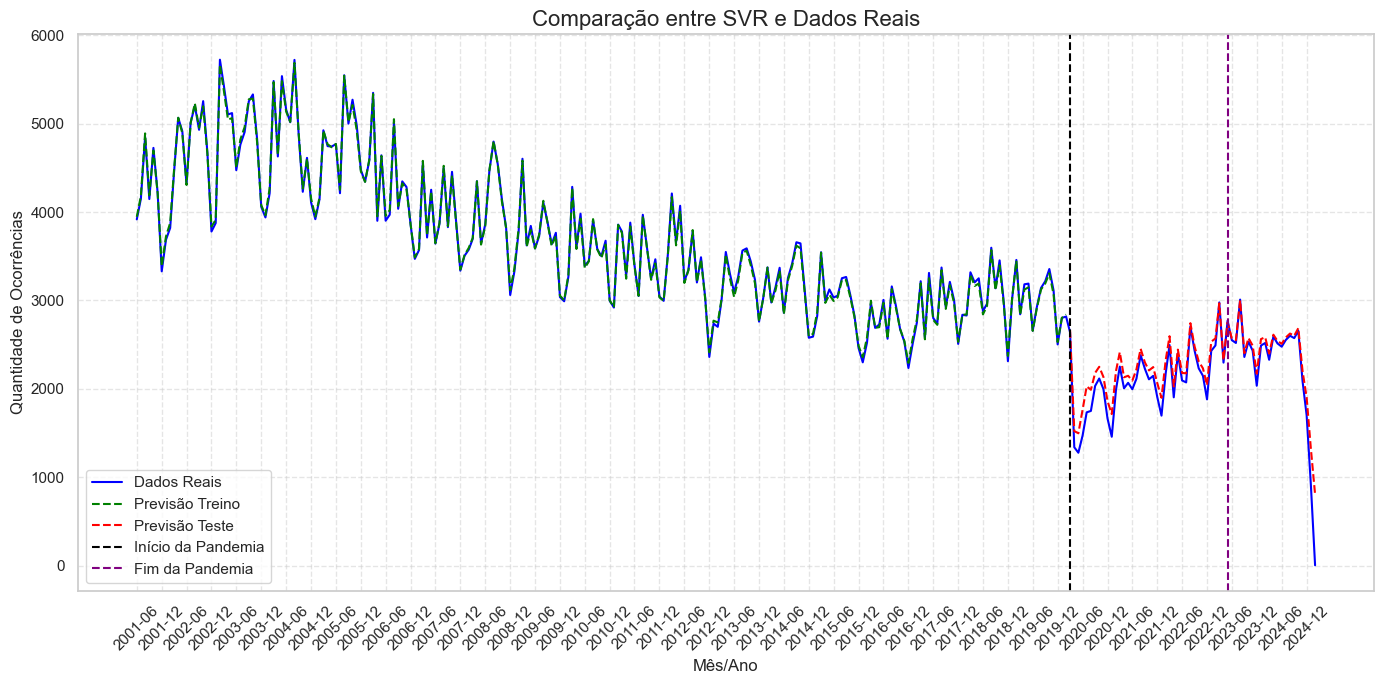

In [117]:
# Comparação dos erros
modelos_treino = {
    "MLP": y_pred_nn_treino,
    "Random Forest": y_pred_rf_treino,
    "XGBoost": y_pred_xgb_treino,
    "SVR": y_pred_svr_treino
}

modelos_teste = {
    "MLP": y_pred_nn_teste,
    "Random Forest": y_pred_rf_teste,
    "XGBoost": y_pred_xgb_teste,
    "SVR": y_pred_svr_teste
}

# Calcular MSE para cada modelo
print("Erro Quadrático Médio (MSE):")
for nome_modelo in modelos_treino.keys():
    # Concatenar previsões de treino e teste
    y_pred_treino = modelos_treino[nome_modelo]
    y_pred_teste = modelos_teste[nome_modelo]
    
    # Calcular MSE separado para treino e teste
    mse_treino = mean_squared_error(dados_agrupados["quantidade"][mask_treino], y_pred_treino)
    mse_teste = mean_squared_error(dados_agrupados["quantidade"][mask_teste], y_pred_teste)
    
    print(f"{nome_modelo} - Treino: {mse_treino:.4f}, Teste: {mse_teste:.4f}")

# Plotar os resultados
for nome_modelo in modelos_treino.keys():
    plt.figure(figsize=(14, 7))
    plt.plot(dados_agrupados["ANO_MES"], dados_agrupados["quantidade"], label="Dados Reais", color="blue")
    plt.plot(dados_agrupados["ANO_MES"][mask_treino], modelos_treino[nome_modelo], label="Previsão Treino", color="green", linestyle="--")
    plt.plot(dados_agrupados["ANO_MES"][mask_teste], modelos_teste[nome_modelo], label="Previsão Teste", color="red", linestyle="--")
    
    # Adicionar linhas verticais para início e fim da pandemia
    plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
    fim_pandemia = pd.to_datetime("2023-05").toordinal()
    plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")
    
    plt.title(f"Comparação entre {nome_modelo} e Dados Reais", fontsize=16)
    plt.xlabel("Mês/Ano")
    plt.ylabel("Quantidade de Ocorrências")
    xticks = pd.date_range(dados_agrupados["ANO_MES"].min(), dados_agrupados["ANO_MES"].max(), freq="6MS")
    plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


#### Gráfico com todos os metodos

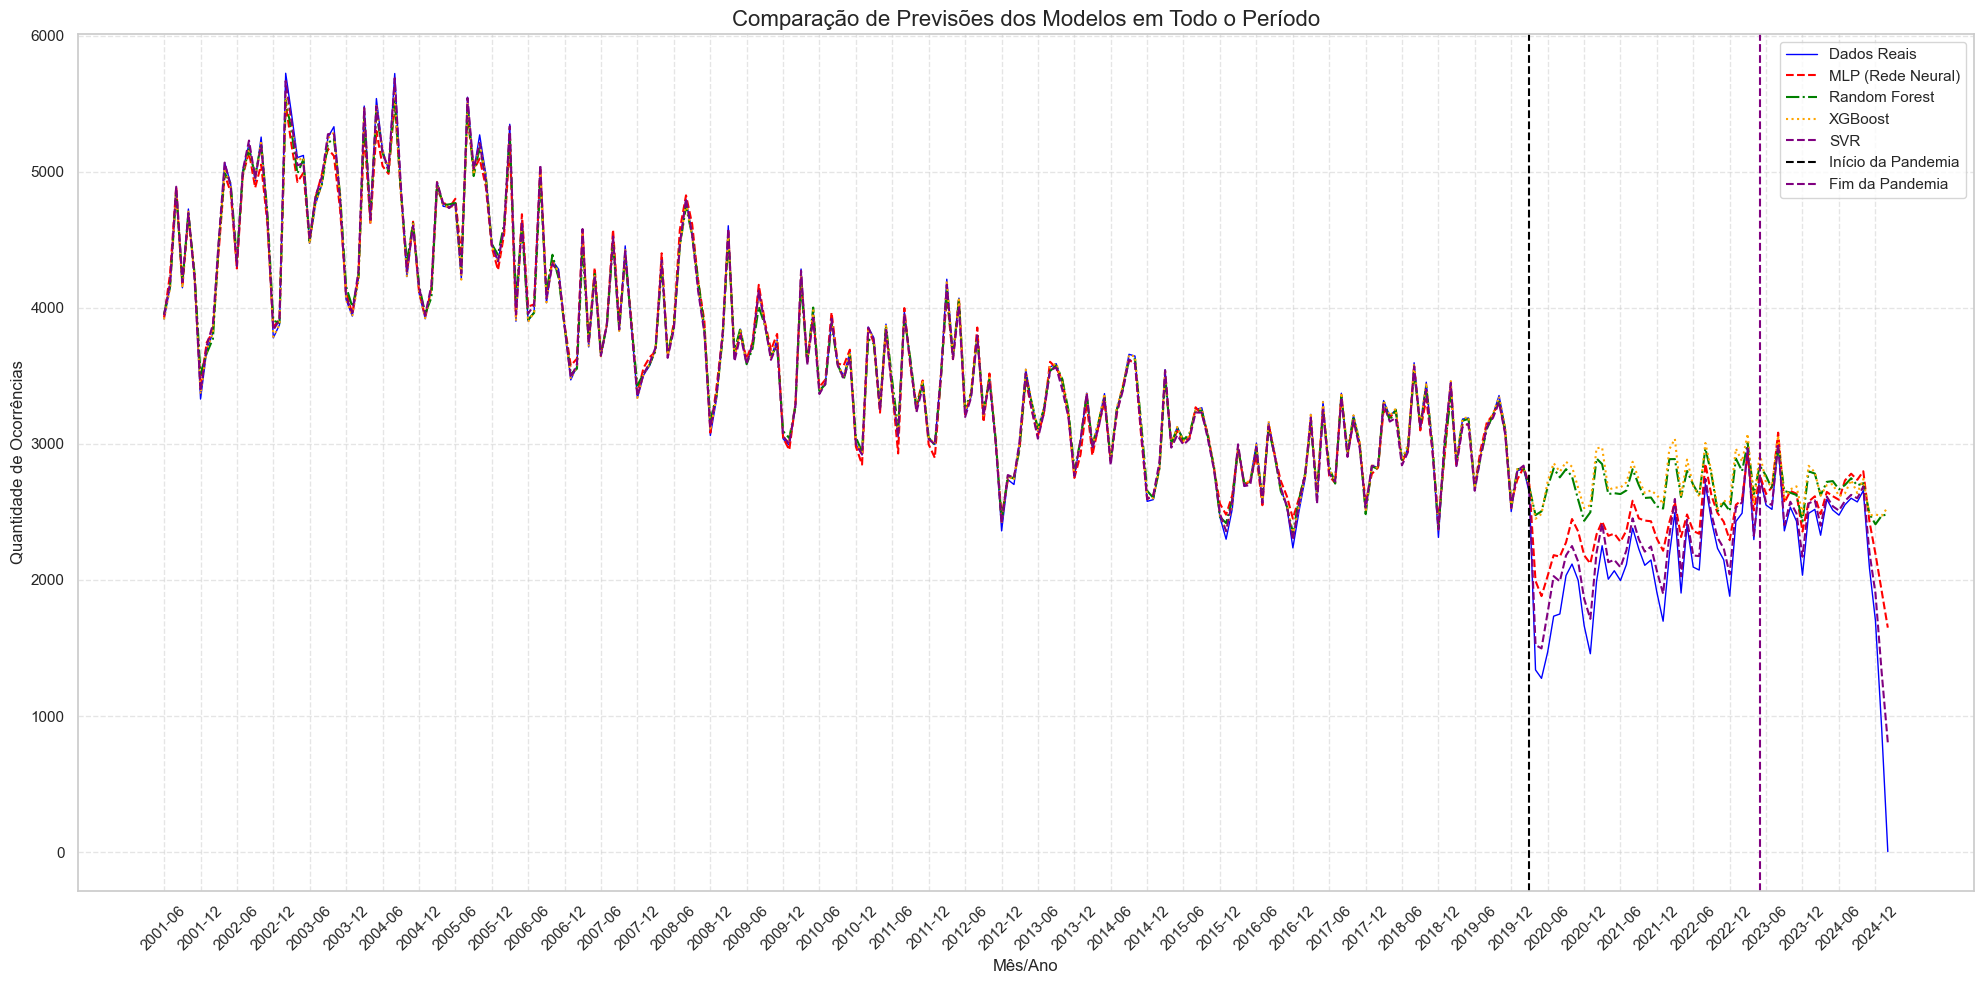

Erro Quadrático Médio (MSE) em Todo o Período:
MLP: 35464.7656
Random Forest: 97875.9907
XGBoost: 105101.7969
SVR: 6812.4666


In [118]:
# Preparação para previsões em todo o período
X_total = X_scaled  # Usar todos os dados
y_real_total = y  # Dados reais (não escalonados)

# Previsões em todo o período
with torch.no_grad():
    y_pred_nn_total_scaled = modelo_nn(torch.tensor(X_total, dtype=torch.float32).to(device)).cpu().numpy()
y_pred_nn_total = inverter_escalonamento(y_pred_nn_total_scaled)

y_pred_rf_total = inverter_escalonamento(modelo_rf.predict(X_total))
y_pred_xgb_total = inverter_escalonamento(modelo_xgb.predict(X_total))
y_pred_svr_total = inverter_escalonamento(modelo_svr.predict(X_total))

# Plotar os resultados (todo o período)
plt.figure(figsize=(20, 10))

# Dados reais
plt.plot(dados_agrupados["ANO_MES"], y_real_total, label="Dados Reais", color="blue", linewidth=1)

# Previsões
plt.plot(dados_agrupados["ANO_MES"], y_pred_nn_total, label="MLP (Rede Neural)", color="red", linestyle="--")
plt.plot(dados_agrupados["ANO_MES"], y_pred_rf_total, label="Random Forest", color="green", linestyle="-.")
plt.plot(dados_agrupados["ANO_MES"], y_pred_xgb_total, label="XGBoost", color="orange", linestyle=":")
plt.plot(dados_agrupados["ANO_MES"], y_pred_svr_total, label="SVR", color="purple", linestyle="--")

# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")

# Adicionar informações ao gráfico
plt.title("Comparação de Previsões dos Modelos em Todo o Período", fontsize=16)
plt.xlabel("Mês/Ano")
plt.ylabel("Quantidade de Ocorrências")
xticks = pd.date_range(dados_agrupados["ANO_MES"].min(), dados_agrupados["ANO_MES"].max(), freq="6MS")
plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Comparar os erros para todo o período
mse_nn_total = mean_squared_error(y_real_total, y_pred_nn_total)
mse_rf_total = mean_squared_error(y_real_total, y_pred_rf_total)
mse_xgb_total = mean_squared_error(y_real_total, y_pred_xgb_total)
mse_svr_total = mean_squared_error(y_real_total, y_pred_svr_total)

print(f"Erro Quadrático Médio (MSE) em Todo o Período:")
print(f"MLP: {mse_nn_total:.4f}")
print(f"Random Forest: {mse_rf_total:.4f}")
print(f"XGBoost: {mse_xgb_total:.4f}")
print(f"SVR: {mse_svr_total:.4f}")


#### Função para plotar gráfico individual

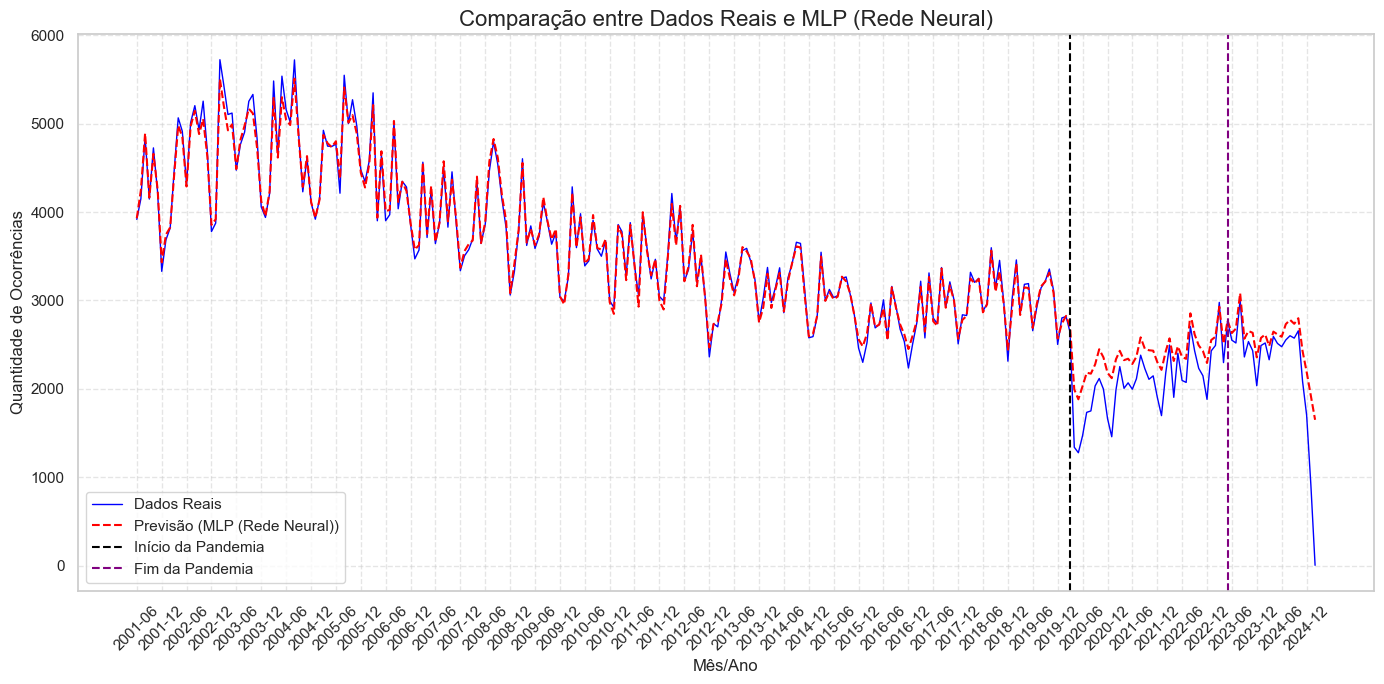

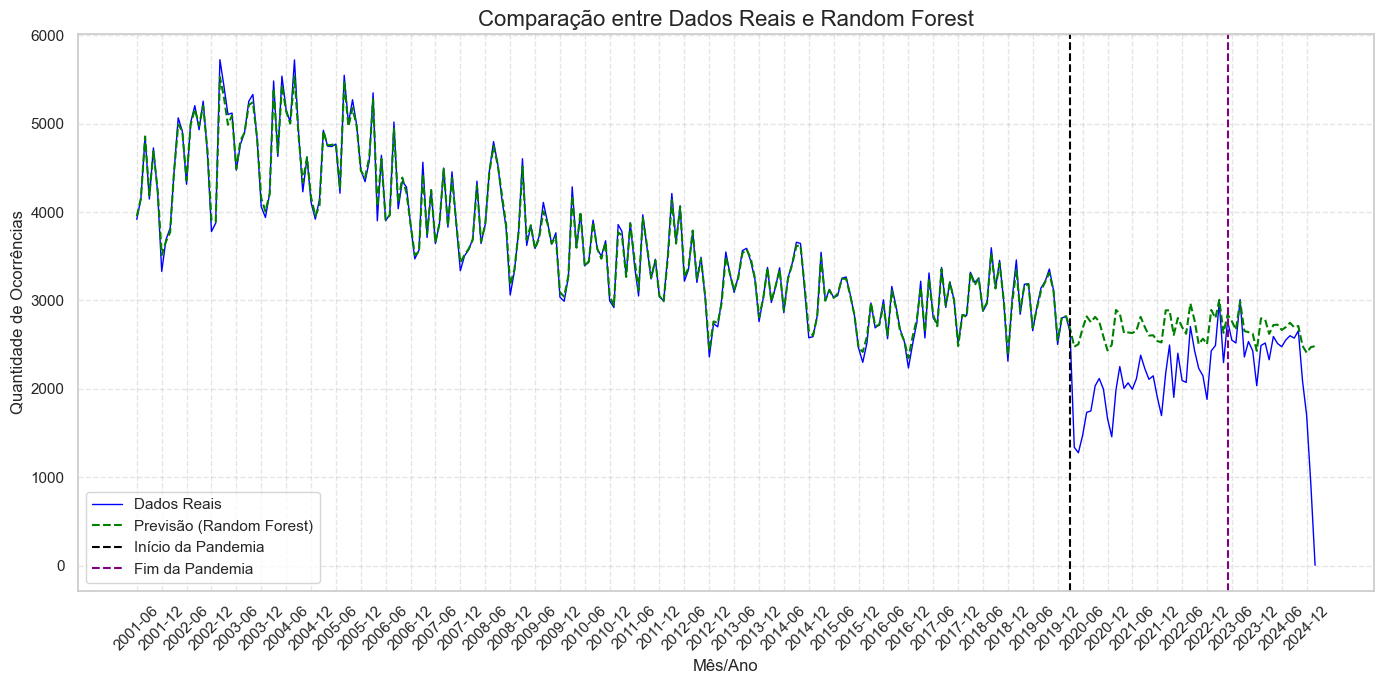

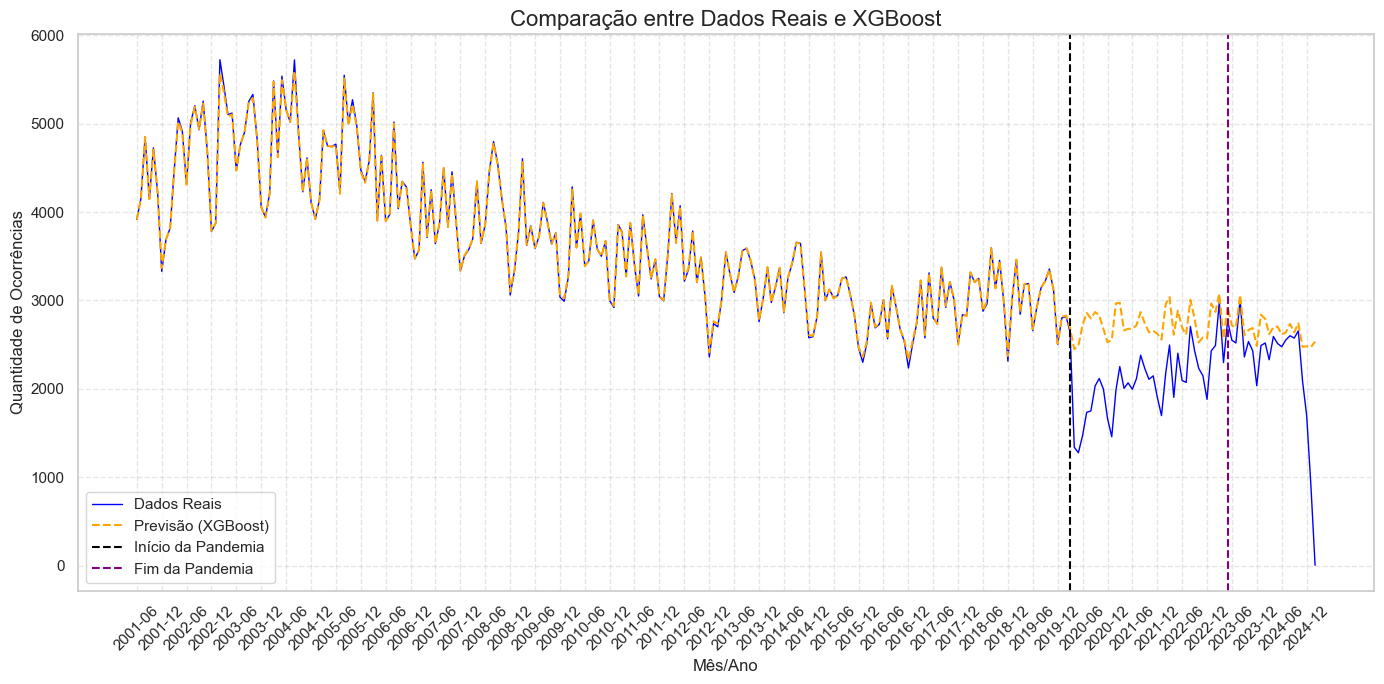

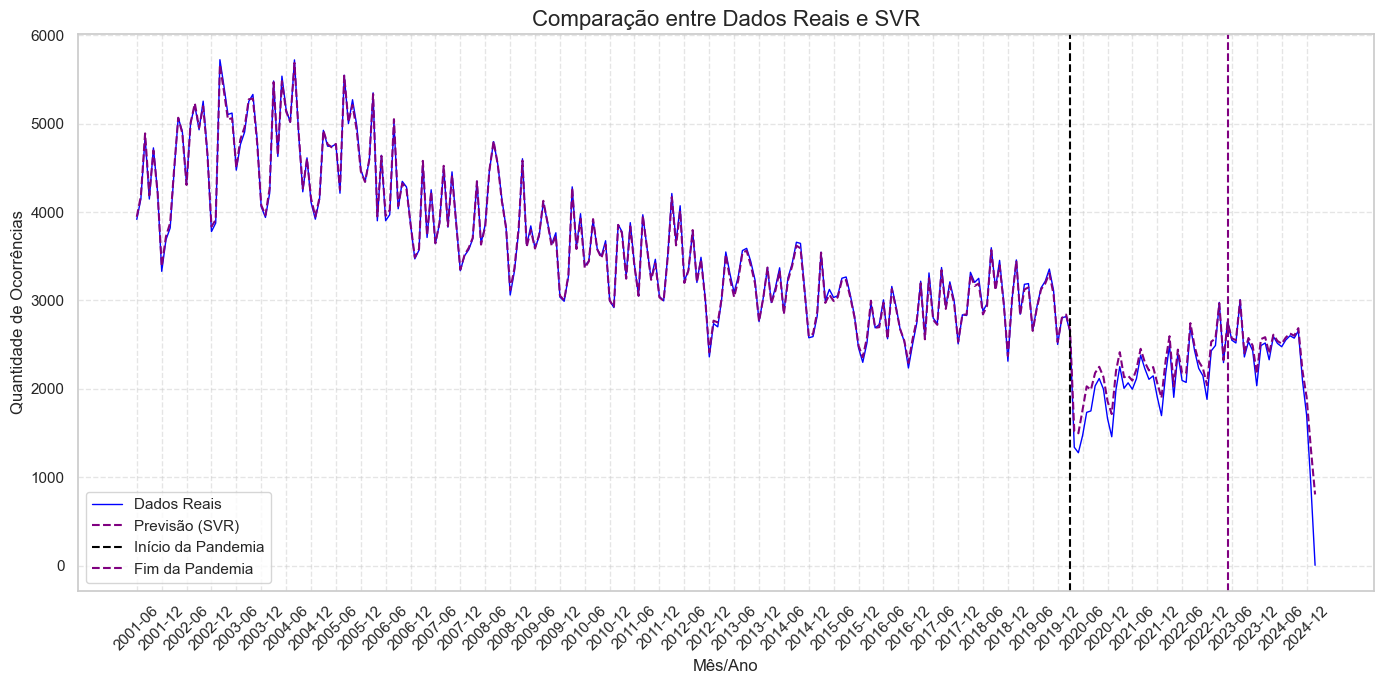

In [119]:
# Função para plotar gráfico individual
def plot_comparacao_modelo(dados_reais, previsoes, modelo_nome, cor_previsao):
    plt.figure(figsize=(14, 7))
    plt.plot(dados_agrupados["ANO_MES"], dados_reais, label="Dados Reais", color="blue", linewidth=1)
    plt.plot(dados_agrupados["ANO_MES"], previsoes, label=f"Previsão ({modelo_nome})", color=cor_previsao, linestyle="--")
    # Adicionar linhas verticais para início e fim da pandemia
    plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
    fim_pandemia = pd.to_datetime("2023-05").toordinal()
    plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")
    plt.title(f"Comparação entre Dados Reais e {modelo_nome}", fontsize=16)
    plt.xlabel("Mês/Ano")
    plt.ylabel("Quantidade de Ocorrências")
    xticks = pd.date_range(dados_agrupados["ANO_MES"].min(), dados_agrupados["ANO_MES"].max(), freq="6MS")
    plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Plotar os gráficos individuais para cada modelo
plot_comparacao_modelo(y_real_total, y_pred_nn_total, "MLP (Rede Neural)", "red")
plot_comparacao_modelo(y_real_total, y_pred_rf_total, "Random Forest", "green")
plot_comparacao_modelo(y_real_total, y_pred_xgb_total, "XGBoost", "orange")
plot_comparacao_modelo(y_real_total, y_pred_svr_total, "SVR", "purple")
